# Stage 1: Spinal Centerline Localisation — Modified 3D U-Net

This notebook implements **Stage 1** of the VerSe pipeline: predicting a single spinal
centerline heatmap from a heavily downsampled (8 mm) full-body CT volume.

The predicted center-of-mass (X, Y) from this heatmap is then fed to Stage 2 as the
spine center for the column crop.

**Pipeline overview:**
1. Import Libraries
2. Configuration & Hyperparameters
3. Data Loading from CSV & JSON
4. Preprocessing Pipeline — RAS reorientation → 8 mm resample → smooth → normalise → center-pad/crop to `[64×64×128]`
5. Ground-Truth Centerline Heatmap Generation (σ = 3 px, fixed)
6. Dataset Class
7. Data Augmentation
8. Stage 1 Modified 3D U-Net Architecture (AvgPool + Trilinear, in=1, out=1)
9. Training Loop (MSE / L2 Loss, Adam, 20 000 iterations)
10. Inference: Extract Spine (X, Y) via Center-of-Mass → feed to Stage 2


## 1. Import Required Libraries

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import nibabel as nib
import nibabel.orientations as nib_ornt
import scipy.ndimage as ndi
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.ndimage import gaussian_filter, zoom, center_of_mass

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Nibabel version:", nib.__version__)
print("All imports successful ✓")


PyTorch version: 2.9.0+cu126
CUDA available: True
Nibabel version: 5.3.3
All imports successful ✓


## 2. Configuration & Hyperparameters

Stage 1 uses very coarse **8 mm isotropic** spacing so that a tiny `[64×64×128]` grid
covers a full-body CT (up to ~512 × 512 × 1024 mm).  
The goal is to regress a **single spinal centerline heatmap** with a fixed σ = 3 px Gaussian
using standard **MSE (L2) loss**.


In [2]:
CFG = {
    # ── Paths ────────────────────────────────────────────────────
    "csv_path":        "/kaggle/input/datasets/ahmed226/verse19-csv/verse19_dataset.csv",
    "checkpoint_path": "best_model_stage1.pth",
    "resume_path":     "/kaggle/input/models/ahmedsayad226/seg-stage1/pytorch/default/1/best_model_stage1_01.pth",          # set to a .pth path to resume training

    # ── Preprocessing (Stage 1 — coarse 8 mm grid) ──────────────
    "target_spacing":    8.0,       # mm — very coarse isotropic spacing
    "smooth_sigma":      0.75,      # Gaussian σ for volume smoothing (same as stage 3)
    "intensity_divisor": 2048.0,    # normalisation denominator   (same as stage 3)
    "intensity_clamp":   1.0,       # clamp range [-1, 1]          (same as stage 3)

    # ── Input grid ───────────────────────────────────────────────
    # [X, Y, Z]  →  covers up to 512 × 512 × 1024 mm at 8 mm spacing
    "input_size": (64, 64, 128),

    # ── Ground-truth heatmap ─────────────────────────────────────
    "sigma_spine": 3.0,             # fixed Gaussian σ (px) for the centerline target

    # ── Augmentation ─────────────────────────────────────────────
    "aug_intensity_scale": (0.75, 1.25),
    "aug_intensity_shift": (-0.25, 0.25),
    "aug_rotation":        (-15, 15),   # degrees  (applied on the downsampled grid)

    # ── Training ─────────────────────────────────────────────────
    "lr":           1e-4,           # Adam lr
    "weight_decay": 5e-4,           # L2 weight regularisation
    "batch_size":   1,
    "iterations":   20_000,
    "log_every":    100,
    "val_every":    500,

    # ── Device ───────────────────────────────────────────────────
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

print("Configuration loaded:")
for k, v in CFG.items():
    print(f"  {k:25s}: {v}")


Configuration loaded:
  csv_path                 : /kaggle/input/datasets/ahmed226/verse19-csv/verse19_dataset.csv
  checkpoint_path          : best_model_stage1.pth
  resume_path              : /kaggle/input/models/ahmedsayad226/seg-stage1/pytorch/default/1/best_model_stage1_01.pth
  target_spacing           : 8.0
  smooth_sigma             : 0.75
  intensity_divisor        : 2048.0
  intensity_clamp          : 1.0
  input_size               : (64, 64, 128)
  sigma_spine              : 3.0
  aug_intensity_scale      : (0.75, 1.25)
  aug_intensity_shift      : (-0.25, 0.25)
  aug_rotation             : (-15, 15)
  lr                       : 0.0001
  weight_decay             : 0.0005
  batch_size               : 1
  iterations               : 20000
  log_every                : 100
  val_every                : 500
  device                   : cuda


## 3. Data Loading from CSV & JSON

Same CSV / JSON format as Stage 3. The first JSON entry is direction metadata; the
remaining entries are per-vertebra centroids in the original image's voxel space.


In [ ]:
def parse_centroid_json(json_path):
    """
    Parse the VerSe centroid JSON file.
    Returns:
        direction : list[str]  e.g. ['P','I','R']
        centroids : dict  {label_int: (X, Y, Z)}
    """
    with open(json_path, "r") as f:
        data = json.load(f)

    direction = data[0].get("direction", [])
    centroids = {}
    for entry in data[1:]:
        label = int(entry["label"])
        centroids[label] = (float(entry["X"]), float(entry["Y"]), float(entry["Z"]))
    return direction, centroids


def _is_valid_path(val):
    """Return True if val is a non-empty, non-NaN string."""
    if val is None:
        return False
    try:
        if isinstance(val, float):
            return False
        return isinstance(val, str) and val.strip() != ""
    except Exception:
        return False


def load_subject(row):
    """
    Load a single subject from a CSV row.
    Returns a dict with nibabel image objects + parsed centroids,
    or raises ValueError if required paths are missing.
    """
    required = {"image_path": row.get("image_path"),
                "centroid_json_path": row.get("centroid_json_path")}
    for col, val in required.items():
        if not _is_valid_path(val):
            raise ValueError(f"Column '{col}' is missing or NaN for subject '{row.get('name', '?')}'")

    volume_nib = nib.load(str(row["image_path"]))

    # mask is optional for stage 1 — we only use centroids for the GT heatmap
    mask_nib = None
    if _is_valid_path(row.get("mask_path")):
        mask_nib = nib.load(str(row["mask_path"]))
    else:
        print(f"  ⚠ No mask_path for {row.get('name', '?')} — mask will be None")

    direction, centroids = parse_centroid_json(str(row["centroid_json_path"]))
    return {
        "name":      row["name"],
        "type":      row["type"],
        "volume":    volume_nib,
        "mask":      mask_nib,
        "direction": direction,
        "centroids": centroids,   
    }


# ── Load CSV ─────────────────────────────────────────────────────────────────
df = pd.read_csv(CFG["csv_path"])
print("CSV loaded — columns:", list(df.columns))
print(df.to_string(index=False))

# ── Load all subjects ─────────────────────────────────────────────────────────
subjects = []
for _, row in df.iterrows():
    try:
        subj = load_subject(row)
        subjects.append(subj)
        print(f"\n✓ Loaded subject: {subj['name']}  [{subj['type']}]")
        print(f"  Volume shape : {subj['volume'].shape}  | spacing: {subj['volume'].header.get_zooms()}")
        print(f"  Direction    : {subj['direction']}")
        print(f"  Vertebrae    : {sorted(subj['centroids'].keys())}")
    except ValueError as e:
        print(f"  ✗ Skipped (bad paths): {e}")
    except FileNotFoundError as e:
        print(f"  ✗ Missing file: {e}")

print("\n── Dataset split summary ──────────────────────────────")
print(df.groupby("type").size().rename("subjects").to_frame())


CSV loaded — columns: ['name', 'type', 'image_path', 'mask_path', 'centroid_json_path']
                   name  type                                                                                                                                image_path                                                                                                                                               mask_path                                                                                                                                     centroid_json_path
               verse004 train                  /kaggle/input/datasets/devanshdesai7/verse-19-3d-images/dataset-verse19training/rawdata/sub-verse004/sub-verse004_ct.nii                  /kaggle/input/datasets/devanshdesai7/verse-19-3d-images/dataset-verse19training/derivatives/sub-verse004/sub-verse004_seg-vert_msk.nii                  /kaggle/input/datasets/devanshdesai7/verse-19-3d-images/dataset-verse19training/derivatives/sub-verse004

## 4. Preprocessing Pipeline

Stage 1 shares the **same orientation and normalisation logic** as Stage 3, but with
key differences:

| Step | Stage 3 | Stage 1 |
|------|---------|---------|
| Spacing | 1.0 mm | **8.0 mm** |
| Smooth σ | 0.75 mm | 0.75 mm (same) |
| Normalise | ÷2048, clamp[-1,1] | ÷2048, clamp[-1,1] (same) |
| Crop | 128×128×96 around each vertebra | **Center-pad/crop to [64×64×128]** |

### Coordinate pipeline (identical to Stage 3)
1. `reorient_to_ras` — NIfTI → RAS+ orientation
2. `world_to_voxel` — JSON world-mm → voxel indices using RAS affine
3. `resample_volume` — zoom to **8 mm** isotropic
4. Scale centroid voxel indices by `original_zooms / 8.0`
5. Gaussian smoothing → intensity normalisation
6. **Center-pad/crop** the whole volume to `[64×64×128]` (no per-vertebra crop)
7. Shift all centroid voxel indices by the padding/crop offset


Demo subject: verse004
Raw volume shape : (161, 338, 61)  | spacing: [1.       1.       2.000296] mm


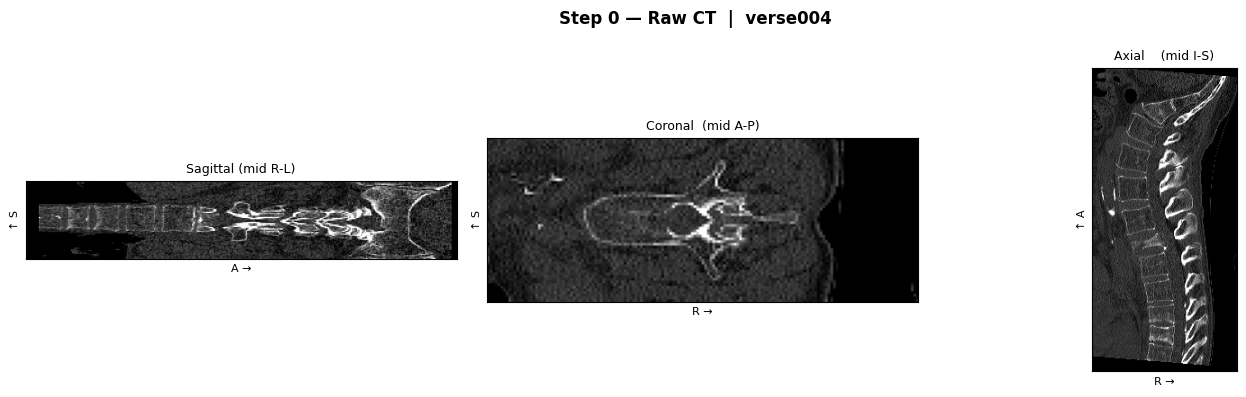


After RAS reorientation → shape: (61, 161, 338)  spacing: [2.000296 1.       1.      ] mm
Centroids remapped to RAS voxel space:
  label 16: (np.int64(32), np.int64(81), np.int64(296))
  label 17: (np.int64(32), np.int64(81), np.int64(274))
  label 18: (np.int64(32), np.int64(84), np.int64(248))
  label 19: (np.int64(31), np.int64(89), np.int64(220))
  label 20: (np.int64(31), np.int64(97), np.int64(196))
  label 21: (np.int64(30), np.int64(107), np.int64(169))
  label 22: (np.int64(29), np.int64(113), np.int64(135))
  label 23: (np.int64(29), np.int64(113), np.int64(102))
  label 24: (np.int64(29), np.int64(103), np.int64(70))


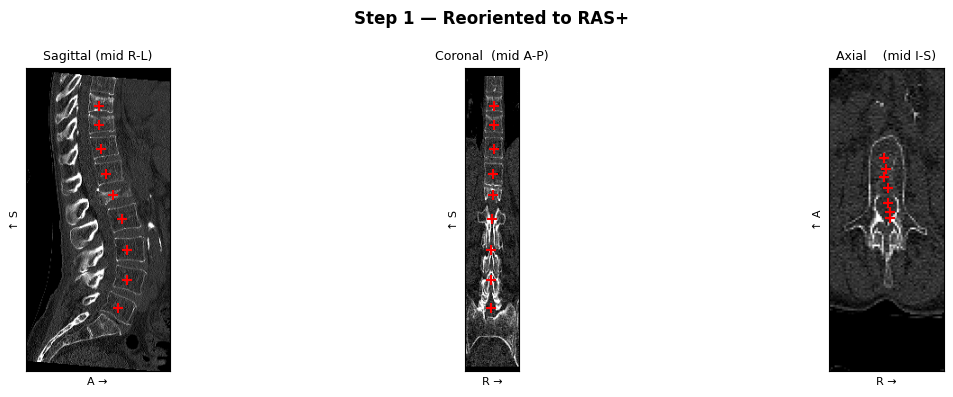

In [ ]:
# ─── Orientation helper ────────────────────────────────────────────────────
# After reorient_to_ras the array axes are (identical to Stage 3):
#   axis-0 (i) = R→L  →  fix i for sagittal  (shows A × S)
#   axis-1 (j) = A→P  →  fix j for coronal   (shows R × S)
#   axis-2 (k) = I→S  →  fix k for axial     (shows R × A)

def plot_ortho_slices(vol, title="", cmap="gray", vmin=None, vmax=None,
                      centroids_vox=None):
    """
    Plot three standard orthogonal mid-slices of a RAS-oriented 3-D volume.
    vol shape: (R, A, S)  — identical convention to Stage 3.

    centroids_vox: list of (i,j,k) voxel indices to overlay as markers.
    """
    nr, na, ns = vol.shape
    mid_r, mid_a, mid_s = nr // 2, na // 2, ns // 2

    # ── same slice definitions as Stage 3 ────────────────────────────────────
    slices = [
        (vol[mid_r, :, :],  "Sagittal (mid R-L)",  "A →",  "↑ S"),
        (vol[:, mid_a, :],  "Coronal  (mid A-P)",  "R →",  "↑ S"),
        (vol[:, :, mid_s],  "Axial    (mid I-S)",  "R →",  "↑ A"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(title, fontsize=12, fontweight="bold")
    for ax, (sl, lbl, xl, yl) in zip(axes, slices):
        ax.imshow(sl.T, cmap=cmap, origin="lower", vmin=vmin, vmax=vmax)
        ax.set_title(lbl, fontsize=9)
        ax.set_xlabel(xl, fontsize=8)
        ax.set_ylabel(yl, fontsize=8)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # Centroid overlays — axis pairs match the slice definitions above
    if centroids_vox:
        for (ci, cj, ck) in centroids_vox:
            # sagittal (fix i): horizontal = j (A), vertical = k (S)
            axes[0].plot(cj, ck, "r+", markersize=7, markeredgewidth=1.5)
            # coronal  (fix j): horizontal = i (R), vertical = k (S)
            axes[1].plot(ci, ck, "r+", markersize=7, markeredgewidth=1.5)
            # axial    (fix k): horizontal = i (R), vertical = j (A)
            axes[2].plot(ci, cj, "r+", markersize=7, markeredgewidth=1.5)

    plt.tight_layout()
    plt.show()


# ── Reorientation — identical to Stage 3 ─────────────────────────────────────
def reorient_to_ras(nib_img):
    """Reorient a NIfTI image to standard RAS+ orientation."""
    orig_ornt = nib.io_orientation(nib_img.affine)
    ras_ornt  = nib.orientations.axcodes2ornt(("R", "A", "S"))
    transform = nib.orientations.ornt_transform(orig_ornt, ras_ornt)
    return nib_img.as_reoriented(transform)


def world_to_voxel(affine, world_xyz):
    """
    Convert a world-space (mm) coordinate to voxel indices using the affine.
    world_xyz : array-like (3,)  in mm
    Returns   : np.ndarray (3,)  integer voxel indices
    """
    inv_affine = np.linalg.inv(affine)
    vox = inv_affine[:3, :3] @ np.array(world_xyz) + inv_affine[:3, 3]
    return np.round(vox).astype(int)


# ── Resampling — same function as Stage 3, target_spacing = 8.0 mm ───────────
def resample_volume(vol, current_spacing, target_spacing=8.0, order=1):
    """Resample volume to target isotropic spacing using scipy.ndimage.zoom."""
    zoom_factors = np.array(current_spacing) / target_spacing
    return zoom(vol, zoom_factors, order=order)


# ── Center-pad / crop: centres the volume inside a fixed [X,Y,Z] grid ────────
def center_pad_crop(vol, target_shape):
    """
    Pad (with zeros) or crop `vol` symmetrically so the output has exactly
    `target_shape` in every dimension.  The physical centre of the input is
    aligned with the centre of the output.

    Returns
    -------
    out    : np.ndarray  shape == target_shape
    offset : np.ndarray (3,)
             How much each voxel index must be shifted to move from the
             original 8mm-RAS coordinate system into the final grid:
               final_idx = original_idx + offset
    """
    in_shape  = np.array(vol.shape)
    out_shape = np.array(target_shape)

    insert = (out_shape - in_shape) // 2   

    out = np.zeros(out_shape, dtype=vol.dtype)

    src_slices, dst_slices = [], []
    for d in range(3):
        src_start = max(0, -insert[d])
        src_end   = src_start + min(in_shape[d], out_shape[d] - max(0, insert[d]))
        dst_start = max(0,  insert[d])
        dst_end   = dst_start + (src_end - src_start)
        src_slices.append(slice(src_start, src_end))
        dst_slices.append(slice(dst_start, dst_end))

    out[tuple(dst_slices)] = vol[tuple(src_slices)]
    offset = np.array([dst_slices[d].start - src_slices[d].start for d in range(3)])
    return out, offset


# ── Full Stage-1 preprocessing pipeline ──────────────────────────────────────
def preprocess_stage1(vol_nib, raw_centroids,
                      target_spacing=8.0,
                      smooth_sigma=0.75,
                      divisor=2048.0,
                      input_size=(64, 64, 128)):
    """
    Full Stage-1 preprocessing — mirrors Stage 3 exactly for the shared steps:
      1. reorient_to_ras          (identical to Stage 3)
      2. JSON → world-mm → RAS voxel   (identical centroid pipeline)
      3. resample to 8 mm isotropic    (Stage 3 uses 1 mm; Stage 1 uses 8 mm)
      4. scale centroids proportionally
      5. Gaussian smooth (σ=0.75)      (identical)
      6. normalise ÷2048, clamp[-1,1]  (identical)
      7. center-pad/crop to [64,64,128] (Stage 1 specific)
      8. shift centroids by pad/crop offset

    Returns
    -------
    vol_out       : np.ndarray float32  shape == input_size
    centroids_out : dict {label: (i,j,k)} in the final [64,64,128] grid
    ras_affine    : (4,4) affine of the RAS-reoriented volume
    orig_affine   : (4,4) original image affine
    """
    orig_affine = vol_nib.affine.copy()

    # ── Step 1: Reorient to RAS+ ─────────────────────────────────────────
    vol_ras    = reorient_to_ras(vol_nib)
    ras_affine = vol_ras.affine.copy()
    zooms_ras  = np.array(vol_ras.header.get_zooms()[:3], dtype=np.float64)
    vol_data   = vol_ras.get_fdata(dtype=np.float32)

    # Centroid: JSON (X,Y,Z) → world-mm via ORIGINAL affine → RAS voxel indices
    centroids_ras = {}
    for label, (x, y, z) in raw_centroids.items():
        world_mm = orig_affine @ np.array([x, y, z, 1.0])       # original→world
        vox_ras  = world_to_voxel(ras_affine, world_mm[:3])      # world→RAS voxel
        vox_ras  = np.clip(vox_ras, 0, np.array(vol_data.shape) - 1)
        centroids_ras[label] = tuple(vox_ras)

    # ── Step 2: Resample to 8 mm isotropic ──────────────────────────────
    vol_8mm = resample_volume(vol_data, zooms_ras, target_spacing, order=1)

    scale = zooms_ras / target_spacing
    centroids_8mm = {}
    for label, (vi, vj, vk) in centroids_ras.items():
        new_idx = np.round(np.array([vi, vj, vk]) * scale).astype(int)
        new_idx = np.clip(new_idx, 0, np.array(vol_8mm.shape) - 1)
        centroids_8mm[label] = tuple(new_idx)

    # ── Step 3: Gaussian smoothing ───────────────────────────────────────
    vol_smooth = gaussian_filter(vol_8mm, sigma=smooth_sigma)

    # ── Step 4: Intensity normalisation ─────────────────────────────────
    vol_norm = np.clip(vol_smooth / divisor, -1.0, 1.0).astype(np.float32)

    # ── Step 5: Center-pad / crop to [64×64×128] ─────────────────────────
    vol_out, offset = center_pad_crop(vol_norm, input_size)

    centroids_out = {}
    for label, vox in centroids_8mm.items():
        new_vox = np.array(vox) + offset
        new_vox = np.clip(new_vox, 0, np.array(input_size) - 1)
        centroids_out[label] = tuple(new_vox.astype(int))

    return vol_out, centroids_out, ras_affine, orig_affine


# ══════════════════════════════════════════════════════════════════════════════
# Demo walkthrough — first subject
# ══════════════════════════════════════════════════════════════════════════════
demo = None
for s in subjects:
    try:
        if os.path.exists(s["volume"].get_filename()):
            demo = s
            break
    except Exception:
        continue

if demo is None:
    print("⚠ No subject found — using synthetic demo data.")
    _vol_arr = np.random.randn(80, 120, 60).astype(np.float32) * 500
    _affine  = np.diag([1.5, 1.5, 2.0, 1.0])
    demo = {
        "name":      "synthetic",
        "centroids": {17: (40.0, 60.0, 30.0), 18: (40.0, 65.0, 25.0)},
        "volume":    nib.Nifti1Image(_vol_arr, _affine),
        "mask":      None,
    }

print(f"Demo subject: {demo['name']}")
vol_nib_demo = demo["volume"]
raw_ctr_demo = demo["centroids"]

# ── Step 0: raw scan ──────────────────────────────────────────────────────────
vol_raw   = vol_nib_demo.get_fdata(dtype=np.float32)
zooms_raw = np.array(vol_nib_demo.header.get_zooms()[:3])
print(f"Raw volume shape : {vol_raw.shape}  | spacing: {zooms_raw} mm")
plot_ortho_slices(vol_raw, title=f"Step 0 — Raw CT  |  {demo['name']}",
                  vmin=-200, vmax=1000)

# ── Step 1: Reorient to RAS+ ──────────────────────────────────────────────────
vol_ras_demo = reorient_to_ras(vol_nib_demo)
zooms_ras    = np.array(vol_ras_demo.header.get_zooms()[:3])
vol_ras_arr  = vol_ras_demo.get_fdata(dtype=np.float32)

# Remap centroids: JSON → world-mm (original affine) → RAS voxel (RAS affine)
centroids_ras = {}
for label, (x, y, z) in raw_ctr_demo.items():
    world_mm = vol_nib_demo.affine @ np.array([x, y, z, 1.0])
    vox_ras  = world_to_voxel(vol_ras_demo.affine, world_mm[:3])
    vox_ras  = np.clip(vox_ras, 0, np.array(vol_ras_arr.shape) - 1)
    centroids_ras[label] = tuple(vox_ras)

print(f"\nAfter RAS reorientation → shape: {vol_ras_arr.shape}  spacing: {zooms_ras} mm")
print("Centroids remapped to RAS voxel space:")
for lbl, vox in sorted(centroids_ras.items()):
    print(f"  label {lbl}: {vox}")
plot_ortho_slices(vol_ras_arr,
                  title="Step 1 — Reoriented to RAS+",
                  centroids_vox=list(centroids_ras.values()),
                  vmin=-200, vmax=1000)


After 8 mm resampling → shape: (15, 20, 42)  (covers ≈ [120 160 336] mm)
Centroids at 8 mm voxel space:
  label 16: (np.int64(8), np.int64(10), np.int64(37))
  label 17: (np.int64(8), np.int64(10), np.int64(34))
  label 18: (np.int64(8), np.int64(10), np.int64(31))
  label 19: (np.int64(8), np.int64(11), np.int64(28))
  label 20: (np.int64(8), np.int64(12), np.int64(24))
  label 21: (np.int64(8), np.int64(13), np.int64(21))
  label 22: (np.int64(7), np.int64(14), np.int64(17))
  label 23: (np.int64(7), np.int64(14), np.int64(13))
  label 24: (np.int64(7), np.int64(13), np.int64(9))


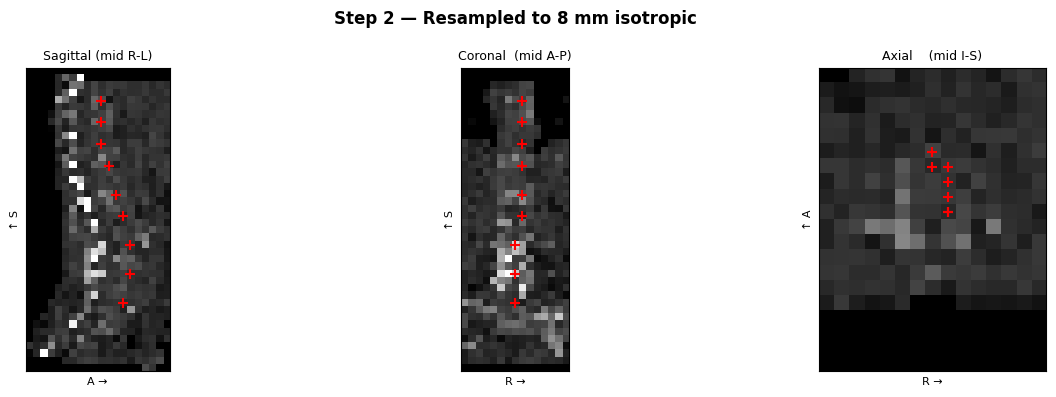

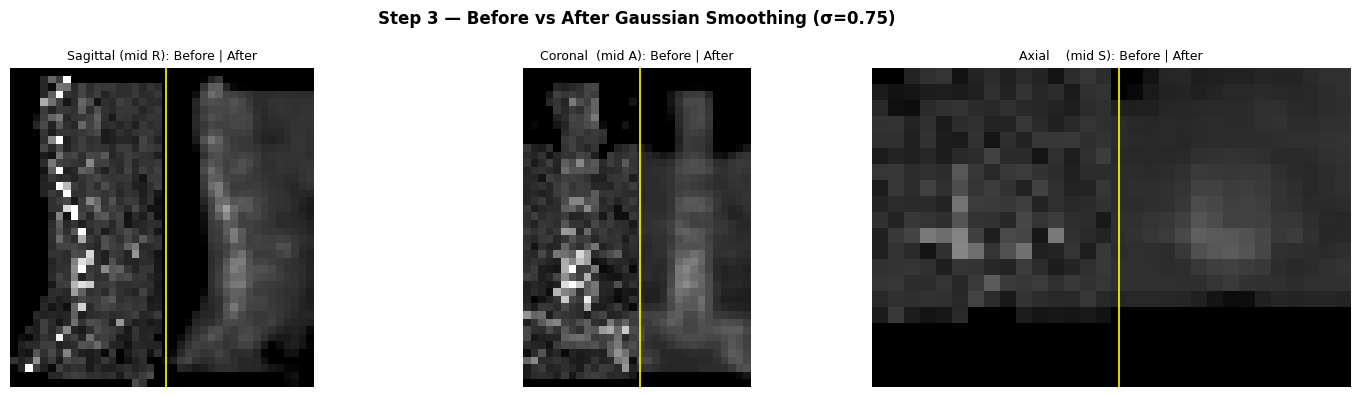

Smoothed volume range: [-1021.0, 546.4]


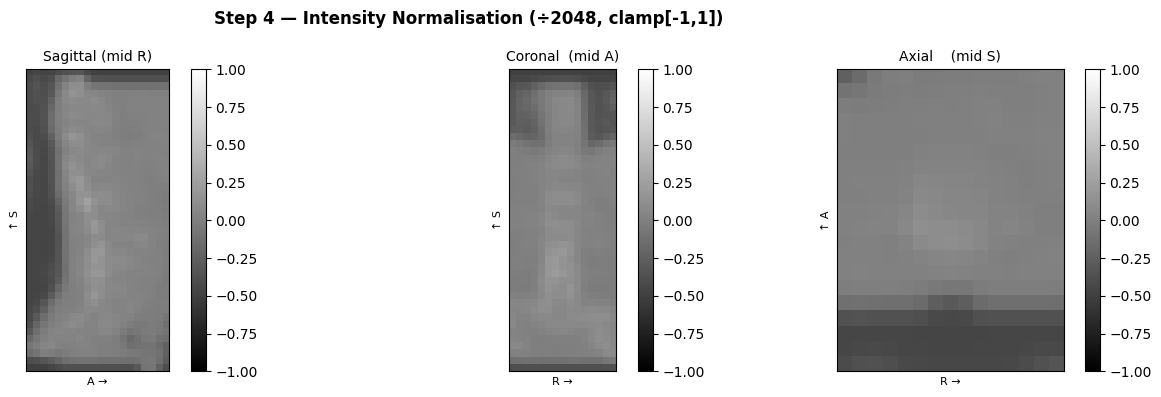

Normalised volume range: [-0.4985, 0.2668]

After center-pad/crop → shape: (64, 64, 128)  (target: (64, 64, 128))
Applied offset: [24 22 43]
Final centroids in the [64×64×128] grid:
  label 16: (np.int64(32), np.int64(32), np.int64(80))
  label 17: (np.int64(32), np.int64(32), np.int64(77))
  label 18: (np.int64(32), np.int64(32), np.int64(74))
  label 19: (np.int64(32), np.int64(33), np.int64(71))
  label 20: (np.int64(32), np.int64(34), np.int64(67))
  label 21: (np.int64(32), np.int64(35), np.int64(64))
  label 22: (np.int64(31), np.int64(36), np.int64(60))
  label 23: (np.int64(31), np.int64(36), np.int64(56))
  label 24: (np.int64(31), np.int64(35), np.int64(52))


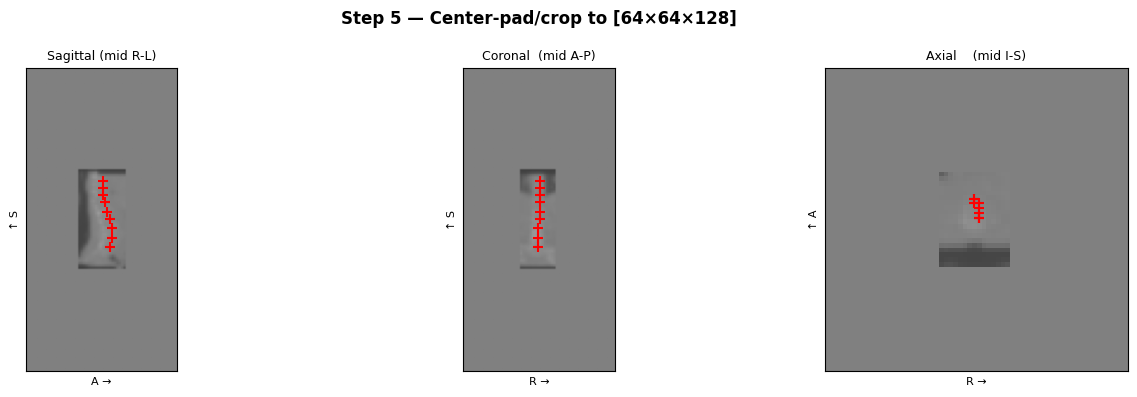

Preprocessing demo complete ✓


In [5]:
# ── Step 2: Resample to 8 mm isotropic ───────────────────────────────────────
vol_8mm_demo = resample_volume(vol_ras_arr, zooms_ras, CFG["target_spacing"], order=1)

scale_8mm    = zooms_ras / CFG["target_spacing"]
centroids_8mm = {}
for label, (vi, vj, vk) in centroids_ras.items():
    new_idx = np.round(np.array([vi, vj, vk]) * scale_8mm).astype(int)
    new_idx = np.clip(new_idx, 0, np.array(vol_8mm_demo.shape) - 1)
    centroids_8mm[label] = tuple(new_idx)

print(f"After 8 mm resampling → shape: {vol_8mm_demo.shape}  "
      f"(covers ≈ {np.array(vol_8mm_demo.shape) * 8} mm)")
print("Centroids at 8 mm voxel space:")
for lbl, vox in sorted(centroids_8mm.items()):
    print(f"  label {lbl}: {vox}")
plot_ortho_slices(vol_8mm_demo,
                  title="Step 2 — Resampled to 8 mm isotropic",
                  centroids_vox=list(centroids_8mm.values()),
                  vmin=-200, vmax=1000)

# ── Step 3: Gaussian smoothing (σ = 0.75 mm) ──────────────────────────────────
vol_smooth_demo = gaussian_filter(vol_8mm_demo, sigma=CFG["smooth_sigma"])

nr, na, ns = vol_8mm_demo.shape
mid_r, mid_a, mid_s = nr // 2, na // 2, ns // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Step 3 — Before vs After Gaussian Smoothing (σ=0.75)",
             fontsize=12, fontweight="bold")
pairs = [
    (vol_8mm_demo[mid_r, :, :], vol_smooth_demo[mid_r, :, :], "Sagittal (mid R): Before | After"),
    (vol_8mm_demo[:, mid_a, :], vol_smooth_demo[:, mid_a, :], "Coronal  (mid A): Before | After"),
    (vol_8mm_demo[:, :, mid_s], vol_smooth_demo[:, :, mid_s], "Axial    (mid S): Before | After"),
]
for ax, (before, after, lbl) in zip(axes, pairs):
    diff_img = np.concatenate([before.T, after.T], axis=1)
    ax.imshow(diff_img, cmap="gray", origin="lower", vmin=-200, vmax=1000)
    ax.set_title(lbl, fontsize=9)
    ax.axvline(before.shape[0], color="yellow", lw=1.2)
    ax.axis("off")
plt.tight_layout()
plt.show()
print(f"Smoothed volume range: [{vol_smooth_demo.min():.1f}, {vol_smooth_demo.max():.1f}]")

# ── Step 4: Intensity normalisation — ÷2048, clamp[-1,1] ─────────────────────
vol_norm_demo = np.clip(vol_smooth_demo / CFG["intensity_divisor"], -1.0, 1.0).astype(np.float32)

nr, na, ns = vol_norm_demo.shape
mid_r, mid_a, mid_s = nr // 2, na // 2, ns // 2

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Step 4 — Intensity Normalisation (÷2048, clamp[-1,1])",
             fontsize=12, fontweight="bold")
for ax, (sl, lbl, xl, yl) in zip(axes, [
        (vol_norm_demo[mid_r, :, :],  "Sagittal (mid R)", "A →", "↑ S"),
        (vol_norm_demo[:, mid_a, :],  "Coronal  (mid A)", "R →", "↑ S"),
        (vol_norm_demo[:, :, mid_s],  "Axial    (mid S)", "R →", "↑ A"),
]):
    im = ax.imshow(sl.T, cmap="gray", origin="lower", vmin=-1, vmax=1)
    ax.set_title(lbl, fontsize=10)
    ax.set_xlabel(xl, fontsize=8); ax.set_ylabel(yl, fontsize=8)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout()
plt.show()
print(f"Normalised volume range: [{vol_norm_demo.min():.4f}, {vol_norm_demo.max():.4f}]")

# ── Step 5: Center-pad / crop to [64×64×128] ──────────────────────────────────
vol_final_demo, offset_demo = center_pad_crop(vol_norm_demo, CFG["input_size"])

centroids_final_demo = {}
for label, vox in centroids_8mm.items():
    new_vox = np.clip(np.array(vox) + offset_demo, 0, np.array(CFG["input_size"]) - 1)
    centroids_final_demo[label] = tuple(new_vox.astype(int))

print(f"\nAfter center-pad/crop → shape: {vol_final_demo.shape}  "
      f"(target: {CFG['input_size']})")
print(f"Applied offset: {offset_demo}")
print("Final centroids in the [64×64×128] grid:")
for lbl, vox in sorted(centroids_final_demo.items()):
    print(f"  label {lbl}: {vox}")

plot_ortho_slices(vol_final_demo,
                  title="Step 5 — Center-pad/crop to [64×64×128]",
                  centroids_vox=list(centroids_final_demo.values()),
                  vmin=-1, vmax=1)
print("Preprocessing demo complete ✓")


## 5. Ground-Truth Centerline Heatmap Generation

A **single** 3-D heatmap for the entire spine: place a fixed-σ Gaussian at every
vertebra centroid and merge via `np.maximum`.

$$h^*_{\text{spine}}(\mathbf{x}) = \max_i \exp\!\left(-\frac{\|\mathbf{x}-\mathbf{c}_i\|^2}{2\sigma_{\text{spine}}^2}\right)$$

- `σ_spine = 3.0 px` (fixed, not learned)
- Output shape: `[64×64×128]` — same as the input volume


GT heatmap shape : (64, 64, 128)
GT heatmap range : [0.0000, 1.0000]
Peak positions   : [np.int64(31), np.int64(35), np.int64(52)]


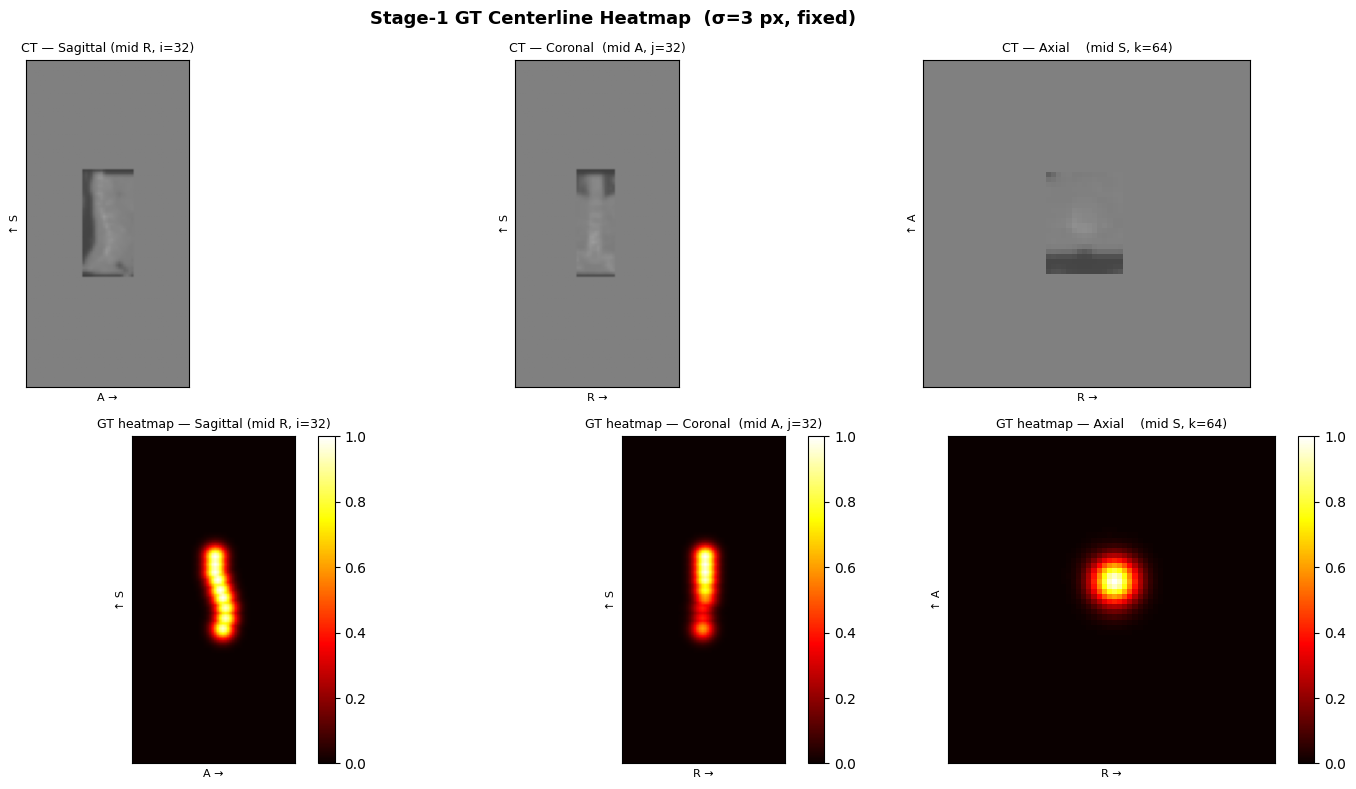

GT heatmap generation demo ✓


In [6]:
def generate_3d_gaussian(center, sigma, shape):
    """
    Generate a 3-D Gaussian blob centred at `center` (i,j,k) with the given σ.

    Parameters
    ----------
    center : array-like (3,) — voxel index (i, j, k) of the blob centre
    sigma  : float           — Gaussian standard deviation in voxels
    shape  : tuple (si, sj, sk) — output array shape

    Returns
    -------
    heatmap : np.ndarray float32  shape == `shape`, peak value ≤ 1
    """
    ci, cj, ck = center
    si, sj, sk = shape
    ii = np.arange(si) - ci
    jj = np.arange(sj) - cj
    kk = np.arange(sk) - ck
    grid_i, grid_j, grid_k = np.meshgrid(ii, jj, kk, indexing="ij")
    heatmap = np.exp(-(grid_i**2 + grid_j**2 + grid_k**2) / (2.0 * sigma**2))
    return heatmap.astype(np.float32)


def generate_spine_centerline_heatmap(centroids, shape, sigma=3.0):
    """
    Build the spinal centerline heatmap h*_spine by placing a Gaussian at
    every ground-truth vertebra centroid and merging with np.maximum.

    Parameters
    ----------
    centroids : dict {label: (i,j,k)} or list of (i,j,k)
    shape     : tuple — output shape (e.g. (64,64,128))
    sigma     : float — Gaussian σ in voxels (fixed at 3.0 for Stage 1)

    Returns
    -------
    heatmap : np.ndarray float32  shape == `shape`
    """
    heatmap = np.zeros(shape, dtype=np.float32)
    coords  = centroids.values() if isinstance(centroids, dict) else centroids
    for coord in coords:
        single = generate_3d_gaussian(coord, sigma=sigma, shape=shape)
        heatmap = np.maximum(heatmap, single)
    return heatmap


# ── Demo: generate and visualise the GT centerline heatmap ───────────────────
gt_heatmap_demo = generate_spine_centerline_heatmap(
    centroids_final_demo, shape=CFG["input_size"], sigma=CFG["sigma_spine"])

print(f"GT heatmap shape : {gt_heatmap_demo.shape}")
print(f"GT heatmap range : [{gt_heatmap_demo.min():.4f}, {gt_heatmap_demo.max():.4f}]")
print(f"Peak positions   : {list(np.unravel_index(np.argmax(gt_heatmap_demo), gt_heatmap_demo.shape))}")

# RAS: axis-0=R(i), axis-1=A(j), axis-2=S(k)
nr, na, ns = CFG["input_size"]
mid_r, mid_a, mid_s = nr // 2, na // 2, ns // 2

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Stage-1 GT Centerline Heatmap  (σ=3 px, fixed)",
             fontsize=13, fontweight="bold")

# Correct RAS slice definitions — identical to plot_ortho_slices:
#   Sagittal : vol[mid_r, :, :]   → horizontal=A(j), vertical=S(k)
#   Coronal  : vol[:, mid_a, :]   → horizontal=R(i), vertical=S(k)
#   Axial    : vol[:, :, mid_s]   → horizontal=R(i), vertical=A(j)
view_defs = [
    (vol_final_demo[mid_r, :, :], gt_heatmap_demo[mid_r, :, :],
     f"Sagittal (mid R, i={mid_r})", "A →", "↑ S"),
    (vol_final_demo[:, mid_a, :], gt_heatmap_demo[:, mid_a, :],
     f"Coronal  (mid A, j={mid_a})", "R →", "↑ S"),
    (vol_final_demo[:, :, mid_s], gt_heatmap_demo[:, :, mid_s],
     f"Axial    (mid S, k={mid_s})", "R →", "↑ A"),
]

for col, (ct_sl, hm_sl, lbl, xl, yl) in enumerate(view_defs):
    # Row 0: CT slice
    axes[0, col].imshow(ct_sl.T, cmap="gray", origin="lower", vmin=-1, vmax=1)
    axes[0, col].set_title(f"CT — {lbl}", fontsize=9)
    axes[0, col].set_xlabel(xl, fontsize=8); axes[0, col].set_ylabel(yl, fontsize=8)
    axes[0, col].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # Row 1: GT heatmap slice
    im = axes[1, col].imshow(hm_sl.T, cmap="hot", origin="lower", vmin=0, vmax=1)
    axes[1, col].set_title(f"GT heatmap — {lbl}", fontsize=9)
    axes[1, col].set_xlabel(xl, fontsize=8); axes[1, col].set_ylabel(yl, fontsize=8)
    axes[1, col].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    plt.colorbar(im, ax=axes[1, col], fraction=0.04)

plt.tight_layout(); plt.show()
print("GT heatmap generation demo ✓")


## 6. Dataset Class

`SpineCenterlineDataset` — one sample per subject (the whole 8 mm volume).  
Each sample is a dict with:
- `ct_vol`   → `Tensor[1, 64, 64, 128]`   (input)
- `heatmap`  → `Tensor[1, 64, 64, 128]`   (GT target)
- `subject`  → `str`


In [7]:
class SpineCenterlineDataset(Dataset):
    """
    One item per subject — the entire coarse 8 mm CT volume + its spine heatmap.

    Preprocessing is done once and cached as .npz on disk to avoid repeated
    resampling of full CT volumes.
    """

    def __init__(self, csv_path, split,
                 input_size=(64, 64, 128),
                 sigma_spine=3.0,
                 augment=None,
                 cache_base_dir="/kaggle/working/stage1_cache",
                 prebuilt_dir="/kaggle/input/datasets/ahmed226/stage1-preprocessed-data"):

        self.input_size  = input_size
        self.sigma_spine = sigma_spine
        self.augment     = augment

        self.cache_dir   = os.path.join(cache_base_dir, split)
        os.makedirs(self.cache_dir, exist_ok=True)
        self.prebuilt_dir = os.path.join(prebuilt_dir, split)

        df       = pd.read_csv(csv_path)
        df_split = df[df["type"] == split].reset_index(drop=True)

        self.samples = []
        total = len(df_split)
        print(f"\nInitialising {split.upper()} dataset ({total} subjects) …")

        for i, (_, row) in enumerate(df_split.iterrows(), 1):
            subj_name = row.get("name", "?")
            print(f"  [{i}/{total}] {subj_name} … ", end="", flush=True)

            try:
                if not _is_valid_path(row.get("image_path")) or \
                   not _is_valid_path(row.get("centroid_json_path")):
                    raise ValueError("Required path columns missing/NaN")

                prebuilt = os.path.join(self.prebuilt_dir, f"{subj_name}.npz")
                local    = os.path.join(self.cache_dir,    f"{subj_name}.npz")

                if os.path.exists(prebuilt):
                    patch_path = prebuilt
                elif os.path.exists(local):
                    patch_path = local
                else:
                    # Pre-process and cache
                    vol_nib_ = nib.load(str(row["image_path"]))
                    _, raw_ctr = parse_centroid_json(str(row["centroid_json_path"]))
                    vol_pp, centroids_pp, _, _ = preprocess_stage1(
                        vol_nib_, raw_ctr,
                        target_spacing=CFG["target_spacing"],
                        smooth_sigma=CFG["smooth_sigma"],
                        divisor=CFG["intensity_divisor"],
                        input_size=self.input_size,
                    )
                    heatmap = generate_spine_centerline_heatmap(
                        centroids_pp, shape=self.input_size, sigma=self.sigma_spine)

                    np.savez_compressed(local, ct_vol=vol_pp, heatmap=heatmap)
                    patch_path = local
                    del vol_nib_, vol_pp, heatmap

                self.samples.append({"patch_path": patch_path, "subject": subj_name})
                print("✓")

            except Exception as e:
                print(f"✗ {e}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s    = self.samples[idx]
        data = np.load(s["patch_path"])
        ct   = data["ct_vol"].astype(np.float32)    # (64,64,128)
        hm   = data["heatmap"].astype(np.float32)   # (64,64,128)

        if self.augment is not None:
            ct, hm = self.augment(ct, hm)

        return {
            "ct_vol":  torch.from_numpy(ct[None]),   # [1,64,64,128]
            "heatmap": torch.from_numpy(hm[None]),   # [1,64,64,128]
            "subject": s["subject"],
        }


# ── Instantiate ───────────────────────────────────────────────────────────────
train_ds = SpineCenterlineDataset(CFG["csv_path"], split="train",
                                  input_size=CFG["input_size"],
                                  sigma_spine=CFG["sigma_spine"])
val_ds   = SpineCenterlineDataset(CFG["csv_path"], split="val",
                                  input_size=CFG["input_size"],
                                  sigma_spine=CFG["sigma_spine"])
test_ds  = SpineCenterlineDataset(CFG["csv_path"], split="test",
                                  input_size=CFG["input_size"],
                                  sigma_spine=CFG["sigma_spine"])

print(f"\n--- Dataset sizes ---")
print(f"Train: {len(train_ds)}  |  Val: {len(val_ds)}  |  Test: {len(test_ds)}")

_demo_ds = next((ds for ds in [train_ds, val_ds, test_ds] if len(ds) > 0), None)
if _demo_ds is not None:
    sample = _demo_ds[0]
    print(f"\nSample keys   : {list(sample.keys())}")
    print(f"  ct_vol  : {sample['ct_vol'].shape}  dtype={sample['ct_vol'].dtype}")
    print(f"  heatmap : {sample['heatmap'].shape}  max={sample['heatmap'].max():.4f}")
    print(f"  subject : {sample['subject']}")
else:
    print("⚠ No samples — check CSV paths.")



Initialising TRAIN dataset (76 subjects) …
  [1/76] verse004 … ✓
  [2/76] verse006 … ✓
  [3/76] verse007 … ✓
  [4/76] verse008 … ✓
  [5/76] verse009 … ✓
  [6/76] verse014 … ✓
  [7/76] verse015 … ✓
  [8/76] verse031 … ✓
  [9/76] verse033 … ✓
  [10/76] verse034 … ✓
  [11/76] verse036 … ✓
  [12/76] verse043 … ✓
  [13/76] verse046 … ✓
  [14/76] verse048 … ✓
  [15/76] verse051 … ✓
  [16/76] verse056 … ✓
  [17/76] verse060 … ✓
  [18/76] verse061 … ✓
  [19/76] verse063 … ✓
  [20/76] verse064 … ✓
  [21/76] verse065 … ✓
  [22/76] verse068 … ✓
  [23/76] verse072 … ✓
  [24/76] verse074 … ✓
  [25/76] verse075 … ✓
  [26/76] verse082 … ✓
  [27/76] verse088 … ✓
  [28/76] verse091 … ✓
  [29/76] verse096 … ✓
  [30/76] verse097 … ✓
  [31/76] verse100 … ✓
  [32/76] verse102 … ✓
  [33/76] verse104 … ✓
  [34/76] verse105 … ✓
  [35/76] verse107 … ✓
  [36/76] verse111 … ✓
  [37/76] verse112 … ✓
  [38/76] verse113 … ✓
  [39/76] verse122 … ✓
  [40/76] verse127 … ✓
  [41/76] verse133 … ✓
  [42/76] verse134 … ✓

## 7. Data Augmentation

Same intensity + small-rotation strategy as Stage 3.  
The GT heatmap is also rotated (unlike Stage 3 where the heatmap is always centred),
because here the heatmap encodes the **absolute spatial location** of the spine.


Stage-1 augmentation pipeline created ✓


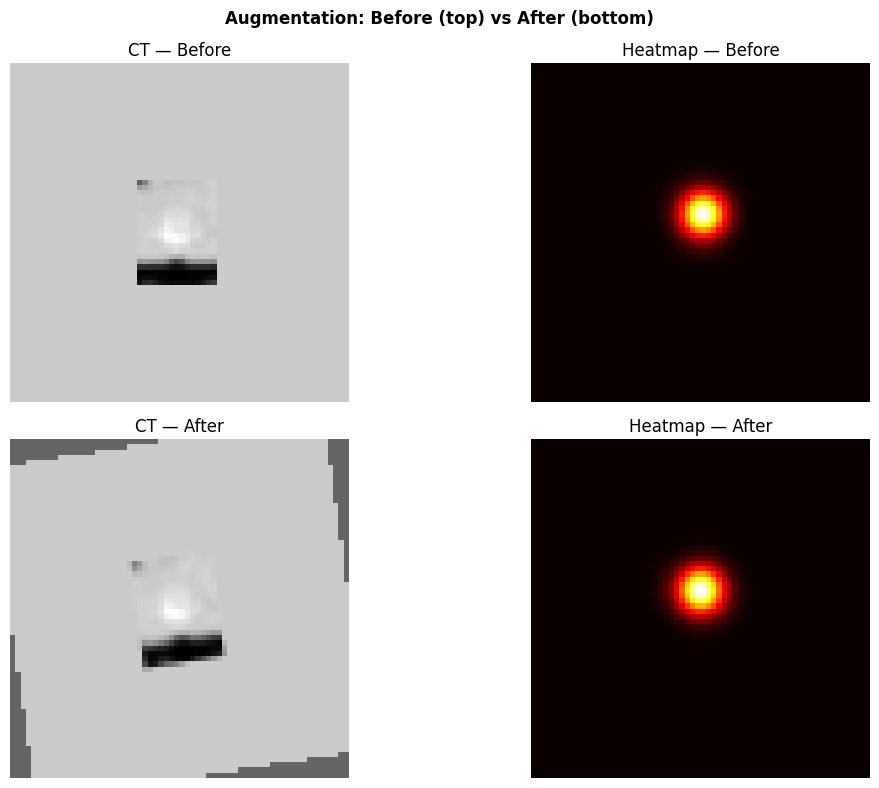

Augmentation attached to train dataset ✓


In [ ]:
class Augment3D_Stage1:
    """
    On-the-fly 3-D augmentation for Stage 1.

    - Intensity jitter: applied to CT only (heatmap is never intensity-augmented)
    - Small rotation:   applied jointly to CT and heatmap, preserving spatial layout
    """

    def __init__(self, cfg):
        self.int_scale = cfg["aug_intensity_scale"]
        self.int_shift = cfg["aug_intensity_shift"]
        self.rot       = cfg.get("aug_rotation", (-15, 15))

    @staticmethod
    def _build_rot_matrix(shape, rx, ry, rz):
        cx, cy, cz = [s / 2.0 for s in shape]
        cos_x, sin_x = np.cos(rx), np.sin(rx)
        cos_y, sin_y = np.cos(ry), np.sin(ry)
        cos_z, sin_z = np.cos(rz), np.sin(rz)
        Rx = np.array([[1,     0,      0    ],
                       [0,  cos_x, -sin_x   ],
                       [0,  sin_x,  cos_x   ]])
        Ry = np.array([[ cos_y, 0, sin_y],
                       [0,      1, 0    ],
                       [-sin_y, 0, cos_y]])
        Rz = np.array([[cos_z, -sin_z, 0],
                       [sin_z,  cos_z, 0],
                       [0,      0,     1]])
        R      = Rz @ Ry @ Rx
        offset = np.array([cx, cy, cz]) - R @ np.array([cx, cy, cz])
        return R, offset

    def __call__(self, ct, heatmap):
        """
        ct      : np.ndarray float32  shape (64,64,128)
        heatmap : np.ndarray float32  shape (64,64,128)
        """
        # 1. Intensity augmentation — CT only
        scale = np.random.uniform(*self.int_scale)
        shift = np.random.uniform(*self.int_shift)
        ct    = np.clip(ct * scale + shift, -1.0, 1.0)

        # 2. Small rotation — both CT and heatmap
        r       = [np.radians(np.random.uniform(*self.rot)) for _ in range(3)]
        R, off  = self._build_rot_matrix(ct.shape, *r)
        ct      = ndi.affine_transform(ct,      R, offset=off, order=1, cval=0.0)
        heatmap = ndi.affine_transform(heatmap, R, offset=off, order=1, cval=0.0)
        heatmap = np.clip(heatmap, 0.0, 1.0)   

        return ct.astype(np.float32), heatmap.astype(np.float32)


train_augment = Augment3D_Stage1(CFG)
print("Stage-1 augmentation pipeline created ✓")

# ── Before / after visual check ───────────────────────────────────────────────
if _demo_ds is not None:
    _s   = _demo_ds[0]
    _ct  = _s["ct_vol"][0].numpy()
    _hm  = _s["heatmap"][0].numpy()
    _ct_aug, _hm_aug = train_augment(_ct.copy(), _hm.copy())

    mid_k = CFG["input_size"][2] // 2
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle("Augmentation: Before (top) vs After (bottom)", fontsize=12, fontweight="bold")
    axes[0, 0].imshow(_ct[:, :, mid_k].T,     cmap="gray", origin="lower"); axes[0, 0].set_title("CT — Before")
    axes[0, 1].imshow(_hm[:, :, mid_k].T,     cmap="hot",  origin="lower"); axes[0, 1].set_title("Heatmap — Before")
    axes[1, 0].imshow(_ct_aug[:, :, mid_k].T, cmap="gray", origin="lower"); axes[1, 0].set_title("CT — After")
    axes[1, 1].imshow(_hm_aug[:, :, mid_k].T, cmap="hot",  origin="lower"); axes[1, 1].set_title("Heatmap — After")
    for ax in axes.ravel():
        ax.axis("off")
    plt.tight_layout(); plt.show()

# Attach to training dataset
train_ds.augment = train_augment
print("Augmentation attached to train dataset ✓")


## 8. Stage-1 Modified 3D U-Net Architecture

**Same modified 3D U-Net as Stage 3** — the description explicitly states this.

Key differences vs Stage 3:
| Property | Stage 3 | Stage 1 |
|----------|---------|---------|
| `in_channels` | 2 (CT + heatmap) | **1** (CT only) |
| `out_channels` | 1 (binary mask) | **1** (centerline heatmap — no sigmoid, raw logits → MSE) |
| Pooling | AvgPool3d(2) | AvgPool3d(2) ✓ same |
| Upsample | trilinear | trilinear ✓ same |
| Filters | 64 | 64 ✓ same |
| Depth | 5 levels | 5 levels ✓ same |
| Kernel | 3×3×3 | 3×3×3 ✓ same |
| Final activation | Sigmoid | **None** (MSE loss needs raw output) |


In [9]:
class ConvBlock3D(nn.Module):
    """Two consecutive Conv3d(3×3×3) + LeakyReLU(0.01) blocks (same-padding)."""
    def __init__(self, in_ch, out_ch=64):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch,  out_ch, kernel_size=3, padding=1, bias=True),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1, bias=True),
            nn.LeakyReLU(0.01, inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet3D_Stage1(nn.Module):
    """
    Modified 3D U-Net for Stage 1 spinal centerline regression.

    Architecture (identical to Stage 3 except I/O channels and final activation):
      - AvgPool3d(2) downsampling
      - Trilinear upsampling
      - 5 encoder levels, all 64 filters, 3×3×3 kernels
      - Input  : [B, 1, 64, 64, 128]   (CT volume)
      - Output : [B, 1, 64, 64, 128]   (predicted heatmap, NO sigmoid — trained with MSE)
    """

    def __init__(self, in_channels=1, num_filters=64):
        super().__init__()
        f = num_filters

        # ── Encoder ────────────────────────────────────────────────────────
        self.enc1 = ConvBlock3D(in_channels, f)  # [B,f, 64, 64,128]
        self.enc2 = ConvBlock3D(f, f)             # [B,f, 32, 32, 64]
        self.enc3 = ConvBlock3D(f, f)             # [B,f, 16, 16, 32]
        self.enc4 = ConvBlock3D(f, f)             # [B,f,  8,  8, 16]

        # ── Bottleneck (level 5) ────────────────────────────────────────────
        self.bottleneck = ConvBlock3D(f, f)       # [B,f,  4,  4,  8]

        # ── Pooling & Upsampling ────────────────────────────────────────────
        self.pool = nn.AvgPool3d(2)
        self.up   = nn.Upsample(scale_factor=2, mode="trilinear", align_corners=False)

        # ── Decoder (skip concat doubles ch → 2f → f) ──────────────────────
        self.dec4 = ConvBlock3D(f * 2, f)
        self.dec3 = ConvBlock3D(f * 2, f)
        self.dec2 = ConvBlock3D(f * 2, f)
        self.dec1 = ConvBlock3D(f * 2, f)

        # ── Output head — NO sigmoid (MSE loss on raw values) ──────────────
        self.head = nn.Sequential(
            nn.Conv3d(f, 1, kernel_size=1)
        )

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)                     # [B,f, 64, 64,128]
        e2 = self.enc2(self.pool(e1))          # [B,f, 32, 32, 64]
        e3 = self.enc3(self.pool(e2))          # [B,f, 16, 16, 32]
        e4 = self.enc4(self.pool(e3))          # [B,f,  8,  8, 16]

        # Bottleneck
        bn = self.bottleneck(self.pool(e4))    # [B,f,  4,  4,  8]

        # Decoder
        d4 = self.dec4(torch.cat([self.up(bn), e4], dim=1))   # [B,f,  8,  8, 16]
        d3 = self.dec3(torch.cat([self.up(d4), e3], dim=1))   # [B,f, 16, 16, 32]
        d2 = self.dec2(torch.cat([self.up(d3), e2], dim=1))   # [B,f, 32, 32, 64]
        d1 = self.dec1(torch.cat([self.up(d2), e1], dim=1))   # [B,f, 64, 64,128]

        return self.head(d1)                   # [B,1, 64, 64,128]


# ── Instantiate & sanity check ────────────────────────────────────────────────
device = torch.device(CFG["device"])
model  = UNet3D_Stage1(in_channels=1, num_filters=64).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model            : Stage-1 Modified 3D U-Net (in=1, out=1)")
print(f"Device           : {device}")
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable_params:,}")

# Forward-pass sanity check
_dummy = torch.zeros(1, 1, *CFG["input_size"], device=device)
with torch.no_grad():
    _out = model(_dummy)
print(f"\nForward pass OK  →  input {list(_dummy.shape)}  →  output {list(_out.shape)}")
print(f"Output range     : [{_out.min().item():.4f}, {_out.max().item():.4f}]")


Model            : Stage-1 Modified 3D U-Net (in=1, out=1)
Device           : cuda
Total params     : 2,325,377
Trainable params : 2,325,377

Forward pass OK  →  input [1, 1, 64, 64, 128]  →  output [1, 1, 64, 64, 128]
Output range     : [0.0068, 0.0099]


## 9. Training Loop

- **Loss**: MSE (L2) between predicted heatmap and GT centerline heatmap
- **Optimiser**: Adam, lr=1e-4, weight_decay=5e-4
- **Iterations**: 20 000
- Best model saved based on validation MSE loss (lower = better)


Loss function    : MSE (L2)
Smoke-test loss  : 8.067739  ✓
Loading checkpoint from '/kaggle/input/models/ahmedsayad226/seg-stage1/pytorch/default/1/best_model_stage1_01.pth' …
Resumed from iteration 2401  (best val MSE so far: 0.006532)

Starting Stage-1 training for 20,000 iterations …
────────────────────────────────────────────────────────────
  Iter   2500/20000  |  Train MSE: 0.008310
  ↳ Val  MSE : 0.006795
  Iter   2600/20000  |  Train MSE: 0.007770
  Iter   2700/20000  |  Train MSE: 0.007857
  Iter   2800/20000  |  Train MSE: 0.008158
  Iter   2900/20000  |  Train MSE: 0.008027
  Iter   3000/20000  |  Train MSE: 0.007710
  ↳ Val  MSE : 0.007067
  Iter   3100/20000  |  Train MSE: 0.008225
  Iter   3200/20000  |  Train MSE: 0.007272
  Iter   3300/20000  |  Train MSE: 0.007102
  Iter   3400/20000  |  Train MSE: 0.006675
  Iter   3500/20000  |  Train MSE: 0.008020
  ↳ Val  MSE : 0.007763
  Iter   3600/20000  |  Train MSE: 0.007209
  Iter   3700/20000  |  Train MSE: 0.006300
  Iter 

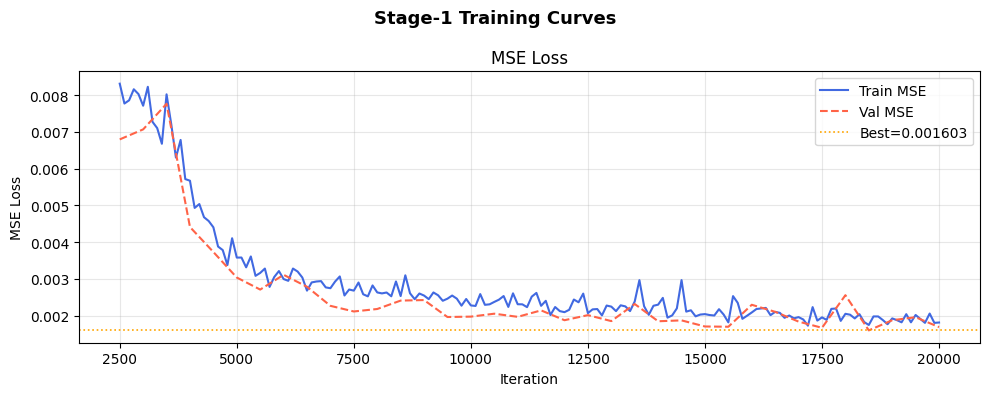

In [10]:
def weighted_mse_loss(pred, target, pos_weight=10.0):
    # Gentle weight map: 10.0 for spine regions, 1.0 for background
    weight_mask = torch.where(target > 0.01, pos_weight, 1.0)
    
    # Standard MSE with the weight mask applied
    weighted_loss = weight_mask * ((pred - target) ** 2)
    
    return weighted_loss.mean()

criterion = weighted_mse_loss
# criterion = nn.MSELoss()

# ── Smoke-test loss ───────────────────────────────────────────────────────────
_pred_t   = torch.randn(1, 1, *CFG["input_size"])
_target_t = torch.clamp(torch.randn(1, 1, *CFG["input_size"]), 0.0, 1.0)
_test_loss = criterion(_pred_t, _target_t)
print(f"Loss function    : MSE (L2)")
print(f"Smoke-test loss  : {_test_loss.item():.6f}  ✓")


def validate_stage1(model, val_loader, criterion, device):
    """Run one validation pass; return mean MSE loss."""
    model.eval()
    losses = []
    with torch.no_grad():
        for batch in val_loader:
            inp  = batch["ct_vol"].to(device)
            gt   = batch["heatmap"].to(device)
            pred = model(inp)
            losses.append(criterion(pred, gt).item())
    model.train()
    return float(np.mean(losses))


# ── DataLoaders ───────────────────────────────────────────────────────────────
def make_loader(ds, shuffle):
    if len(ds) == 0:
        return None
    return DataLoader(ds, batch_size=CFG["batch_size"], shuffle=shuffle,
                      num_workers=2, pin_memory=(device.type == "cuda"), drop_last=False)

train_loader = make_loader(train_ds, shuffle=True)
val_loader   = make_loader(val_ds,   shuffle=False)

if train_loader is None:
    print("⚠ No training samples — falling back to test set for demo.")
    _train_dl = make_loader(test_ds, shuffle=True)
else:
    _train_dl = train_loader

if val_loader is None:
    print("⚠ No validation samples — falling back to test set for demo.")
    _val_dl = make_loader(test_ds, shuffle=False)
else:
    _val_dl = val_loader


# ── Optimiser ─────────────────────────────────────────────────────────────────
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"],
)

# ── Logging structures ────────────────────────────────────────────────────────
train_log_iters, train_log_loss = [], []
val_log_iters,   val_log_loss   = [], []
best_val_loss   = float("inf")
start_iteration = 1

# ── Resume logic ──────────────────────────────────────────────────────────────
if CFG["resume_path"] and os.path.exists(CFG["resume_path"]):
    print(f"Loading checkpoint from '{CFG['resume_path']}' …")
    ckpt = torch.load(CFG["resume_path"], map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    best_val_loss   = ckpt.get("val_loss", float("inf"))
    start_iteration = ckpt.get("iteration", 0) + 1
    print(f"Resumed from iteration {start_iteration}  "
          f"(best val MSE so far: {best_val_loss:.6f})")
else:
    print("Starting training from scratch.")


def infinite_loader(loader):
    while True:
        for batch in loader:
            yield batch


# ── Training loop ──────────────────────────────────────────────────────────────
print(f"\nStarting Stage-1 training for {CFG['iterations']:,} iterations …")
print("─" * 60)

model.train()
running_loss = 0.0
data_iter    = infinite_loader(_train_dl)

for iteration in range(start_iteration, CFG["iterations"] + 1):
    batch = next(data_iter)
    inp   = batch["ct_vol"].to(device)       # [B,1,64,64,128]
    gt    = batch["heatmap"].to(device)      # [B,1,64,64,128]

    optimizer.zero_grad()
    pred = model(inp)
    loss = criterion(pred, gt)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()

    # ── Log training loss ─────────────────────────────────────────────────
    if iteration % CFG["log_every"] == 0:
        avg_loss = running_loss / CFG["log_every"]
        train_log_iters.append(iteration)
        train_log_loss.append(avg_loss)
        running_loss = 0.0
        print(f"  Iter {iteration:6d}/{CFG['iterations']}  |  Train MSE: {avg_loss:.6f}")

    # ── Validation pass ───────────────────────────────────────────────────
    if iteration % CFG["val_every"] == 0 and _val_dl is not None:
        val_loss = validate_stage1(model, _val_dl, criterion, device)
        val_log_iters.append(iteration)
        val_log_loss.append(val_loss)
        print(f"  ↳ Val  MSE : {val_loss:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                "iteration":       iteration,
                "model_state":     model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "val_loss":        val_loss,
            }, CFG["checkpoint_path"])
            print(f"    ★ New best val MSE={val_loss:.6f} — checkpoint saved.")

        # Always save latest for crash recovery
        torch.save({
            "iteration":       iteration,
            "model_state":     model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_loss":        val_loss,
        }, "latest_model_stage1.pth")

print(f"\nTraining complete.  Best Val MSE: {best_val_loss:.6f}")
print(f"Checkpoint saved to: {CFG['checkpoint_path']}")

# ── Training curves ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle("Stage-1 Training Curves", fontsize=13, fontweight="bold")
ax.plot(train_log_iters, train_log_loss, color="royalblue", lw=1.5, label="Train MSE")
if val_log_iters:
    ax.plot(val_log_iters, val_log_loss, color="tomato", lw=1.5,
            linestyle="--", label="Val MSE")
    ax.axhline(best_val_loss, color="orange", lw=1.2, linestyle=":",
               label=f"Best={best_val_loss:.6f}")
ax.set_xlabel("Iteration"); ax.set_ylabel("MSE Loss")
ax.set_title("MSE Loss"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 10. Inference: Extract Spine (X, Y) via Center-of-Mass → Stage 2

After training, Stage 1's job is to produce the **X and Y spine-center coordinates**
that Stage 2 uses to place its column crop.

Steps:
1. Load best checkpoint
2. For every test subject: preprocess → forward pass → get predicted heatmap
3. Apply ReLU (clip negatives) and compute the **3-D center-of-mass**
4. **Only X and Y are passed to Stage 2** (Z is ignored — Stage 2 crops randomly along Z)
5. Rescale from 8 mm voxel space back to the original physical (mm) world space

$$(\hat{x}_{\text{spine}},\, \hat{y}_{\text{spine}}) = \text{CoM}_{x,y}\!\left[\text{ReLU}(\hat{h}_{\text{spine}})\right] \times 8\,\text{mm/voxel}$$


Loaded checkpoint from iteration 18500  (val MSE=0.001603)

Running Stage-1 inference on: verse012
  Predicted spine center (mm):  X=56.3  Y=108.5
  GT spine center      (mm):   X=56.0  Y=112.0
  CoM voxel in [64×64×128] grid: (32.0, 33.6, 64.2)


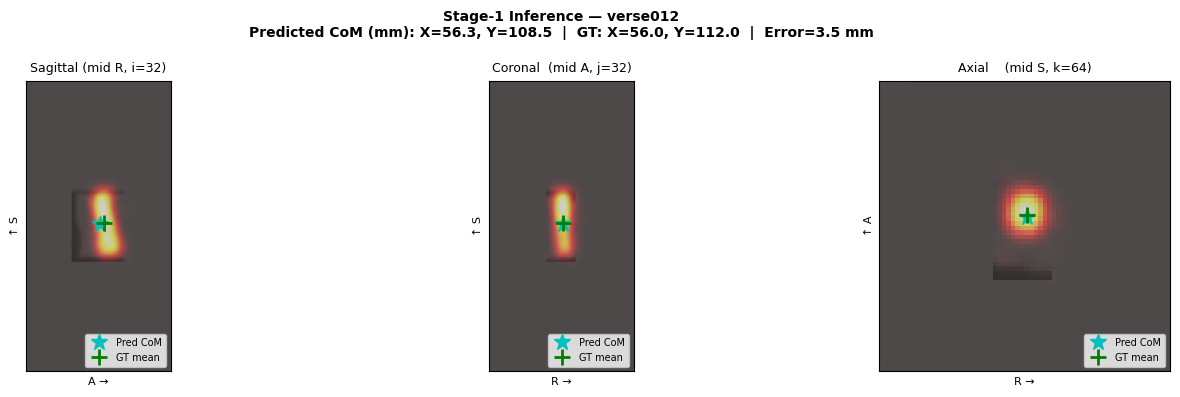


Running Stage-1 inference on: verse020
  Predicted spine center (mm):  X=86.0  Y=192.9
  GT spine center      (mm):   X=76.2  Y=182.6
  CoM voxel in [64×64×128] grid: (31.8, 31.1, 66.3)


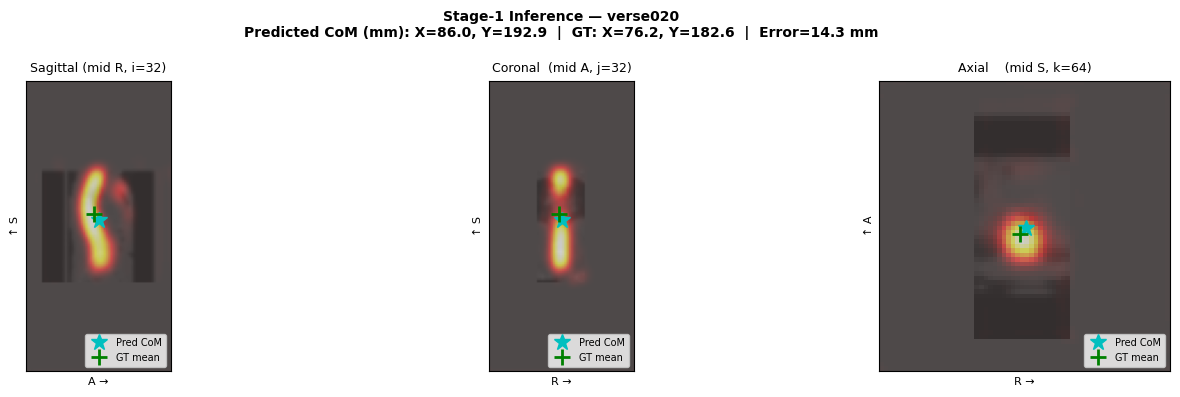


Running Stage-1 inference on: verse029
  Predicted spine center (mm):  X=152.0  Y=190.2
  GT spine center      (mm):   X=147.3  Y=161.4
  CoM voxel in [64×64×128] grid: (32.0, 26.8, 69.8)


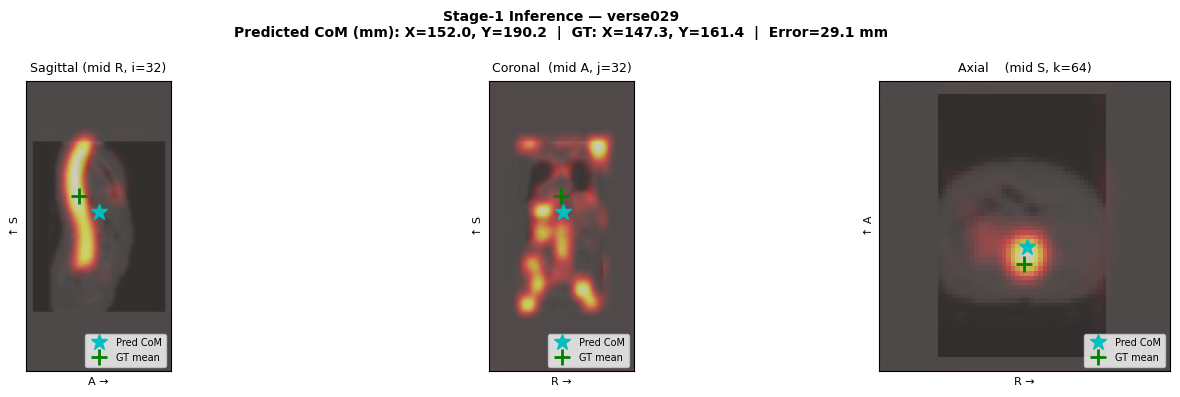


Running Stage-1 inference on: verse032
  Predicted spine center (mm):  X=61.0  Y=105.6
  GT spine center      (mm):   X=58.7  Y=114.7
  CoM voxel in [64×64×128] grid: (31.6, 33.2, 67.4)


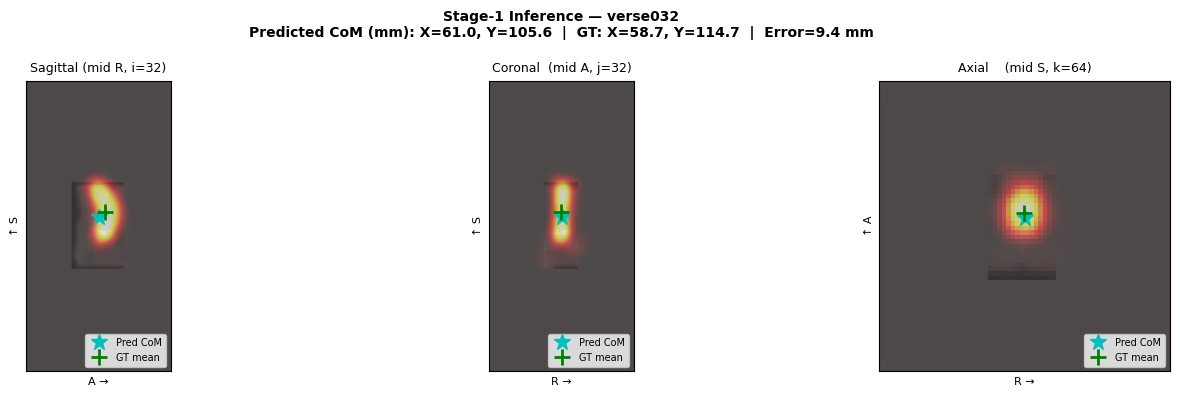


Running Stage-1 inference on: verse038
  Predicted spine center (mm):  X=172.3  Y=159.1
  GT spine center      (mm):   X=160.0  Y=107.4
  CoM voxel in [64×64×128] grid: (31.5, 25.9, 69.2)


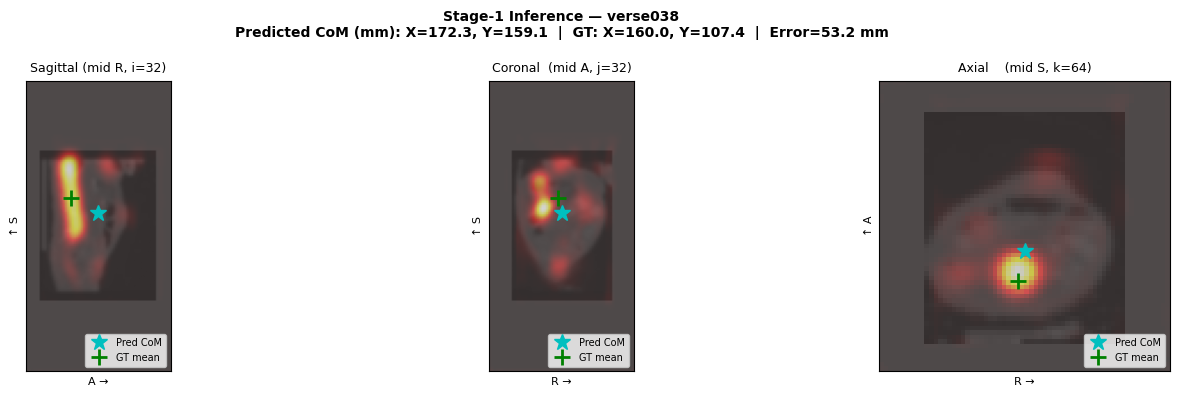


Running Stage-1 inference on: verse040
  Predicted spine center (mm):  X=184.6  Y=157.0
  GT spine center      (mm):   X=184.0  Y=113.8
  CoM voxel in [64×64×128] grid: (31.1, 30.6, 66.4)


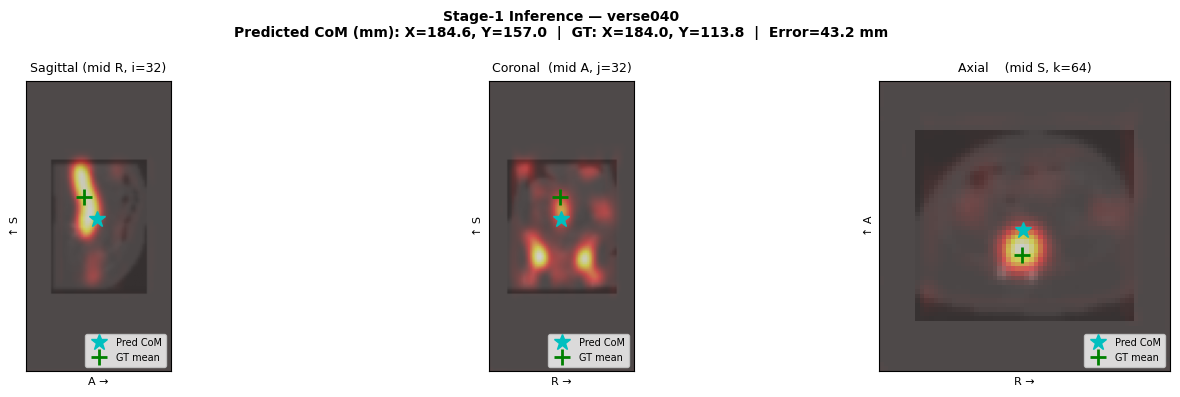


Running Stage-1 inference on: verse050
  Predicted spine center (mm):  X=90.6  Y=238.8
  GT spine center      (mm):   X=88.9  Y=229.2
  CoM voxel in [64×64×128] grid: (32.3, 29.8, 65.9)


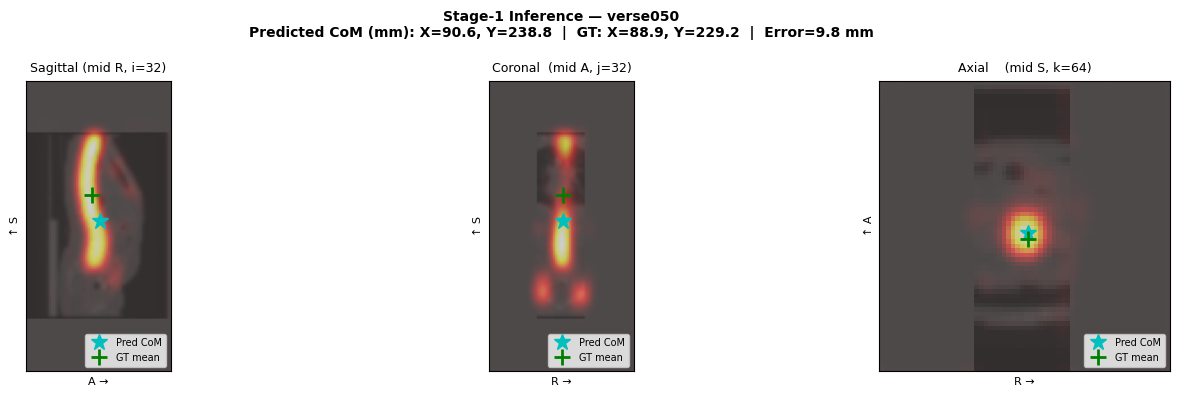


Running Stage-1 inference on: verse053
  Predicted spine center (mm):  X=82.3  Y=150.1
  GT spine center      (mm):   X=84.8  Y=160.0
  CoM voxel in [64×64×128] grid: (32.3, 33.8, 65.8)


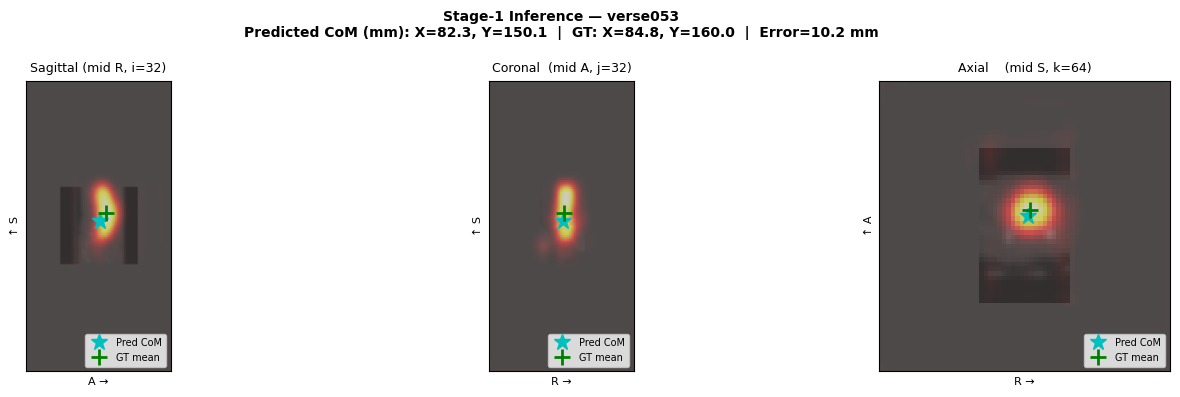


Running Stage-1 inference on: verse054
  Predicted spine center (mm):  X=58.6  Y=105.2
  GT spine center      (mm):   X=52.8  Y=115.2
  CoM voxel in [64×64×128] grid: (32.3, 33.2, 64.4)


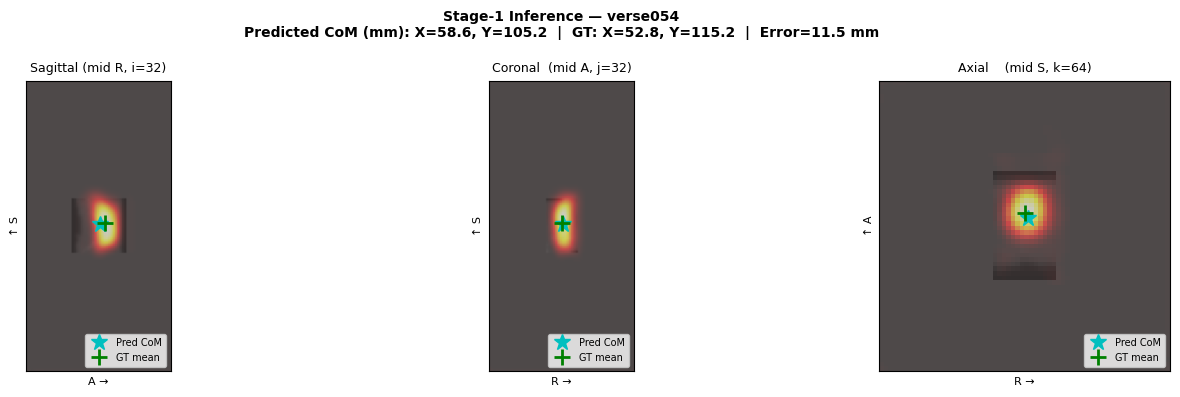


Running Stage-1 inference on: verse055
  Predicted spine center (mm):  X=176.4  Y=187.3
  GT spine center      (mm):   X=162.9  Y=152.0
  CoM voxel in [64×64×128] grid: (32.1, 27.4, 66.0)


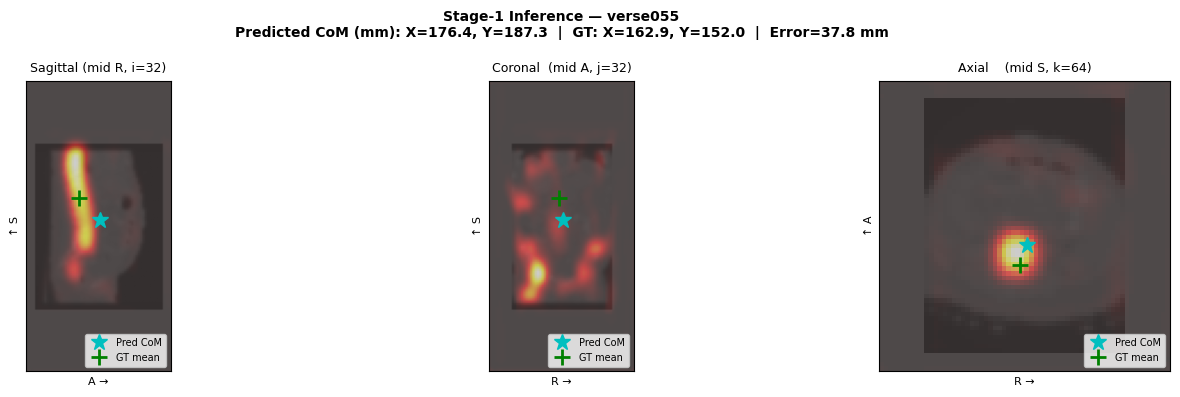


Running Stage-1 inference on: verse059
  Predicted spine center (mm):  X=34.8  Y=97.5
  GT spine center      (mm):   X=41.1  Y=92.6
  CoM voxel in [64×64×128] grid: (32.4, 31.2, 63.2)


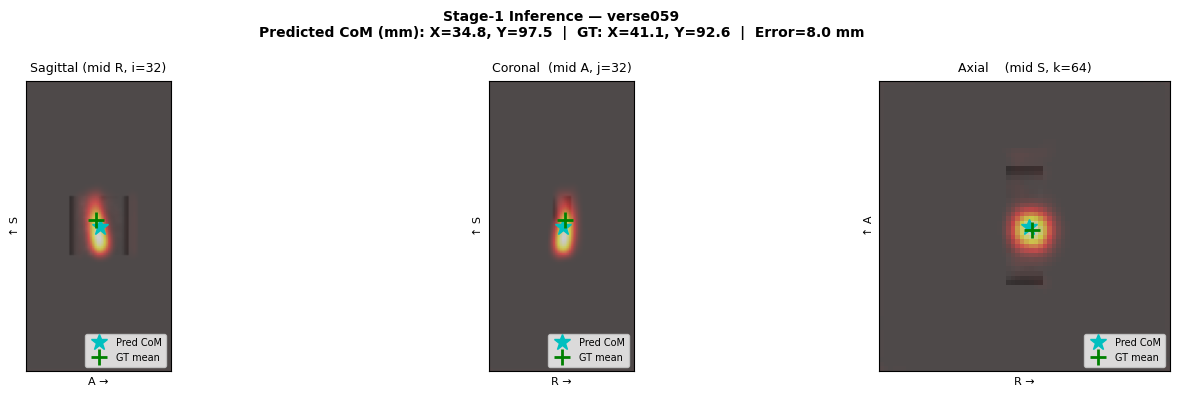


Running Stage-1 inference on: verse066
  Predicted spine center (mm):  X=94.3  Y=153.9
  GT spine center      (mm):   X=96.0  Y=161.6
  CoM voxel in [64×64×128] grid: (31.8, 33.2, 64.5)


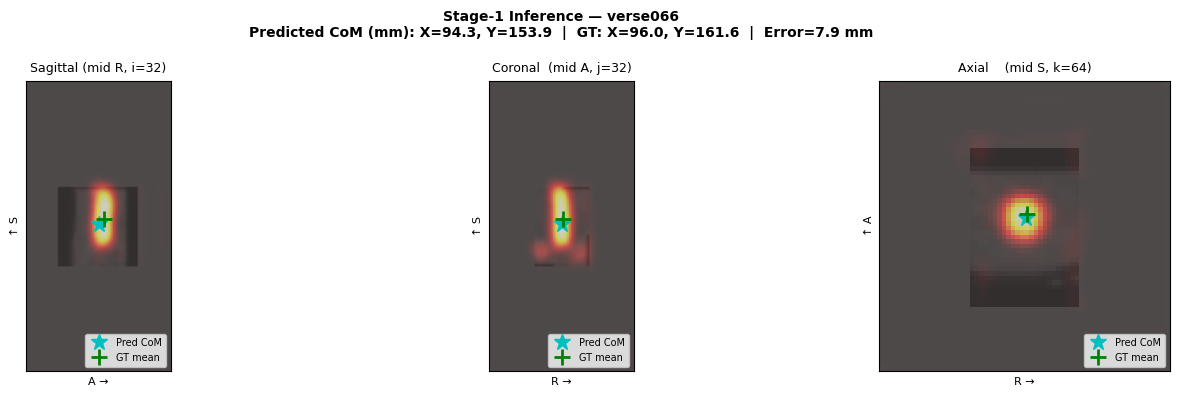


Running Stage-1 inference on: verse070
  Predicted spine center (mm):  X=73.5  Y=91.9
  GT spine center      (mm):   X=67.6  Y=95.1
  CoM voxel in [64×64×128] grid: (31.2, 33.5, 66.2)


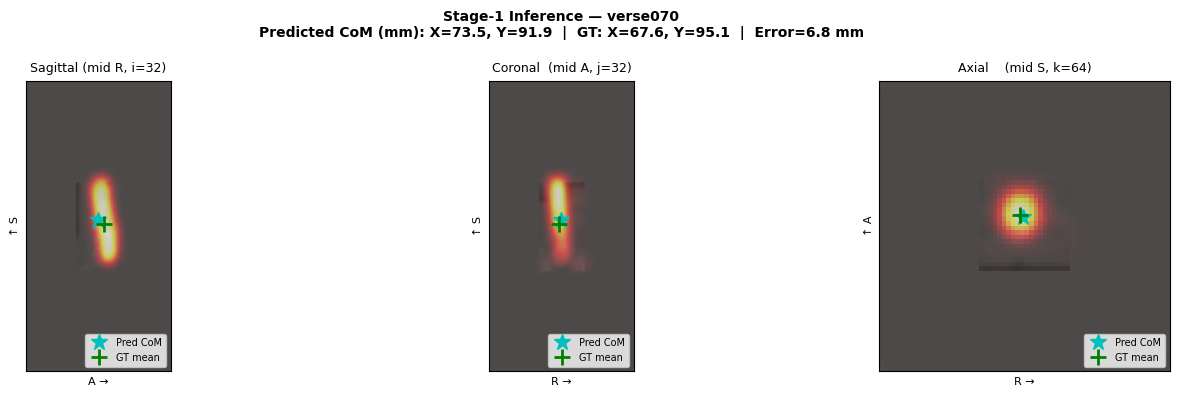


Running Stage-1 inference on: verse081
  Predicted spine center (mm):  X=79.0  Y=82.3
  GT spine center      (mm):   X=76.0  Y=84.0
  CoM voxel in [64×64×128] grid: (31.9, 32.3, 64.1)


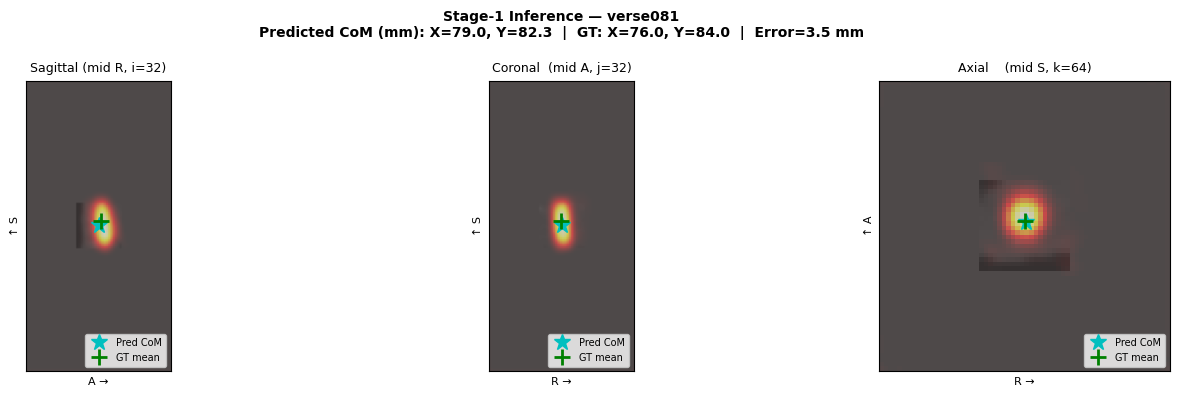


Running Stage-1 inference on: verse083
  Predicted spine center (mm):  X=60.2  Y=99.2
  GT spine center      (mm):   X=57.3  Y=110.7
  CoM voxel in [64×64×128] grid: (31.5, 33.4, 66.2)


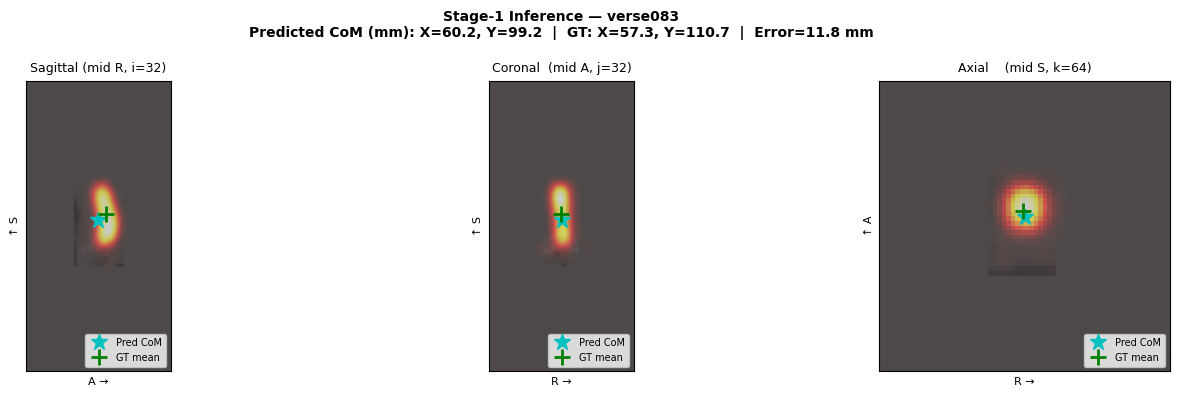


Running Stage-1 inference on: verse085
  Predicted spine center (mm):  X=94.5  Y=98.2
  GT spine center      (mm):   X=89.6  Y=99.2
  CoM voxel in [64×64×128] grid: (31.8, 32.3, 64.4)


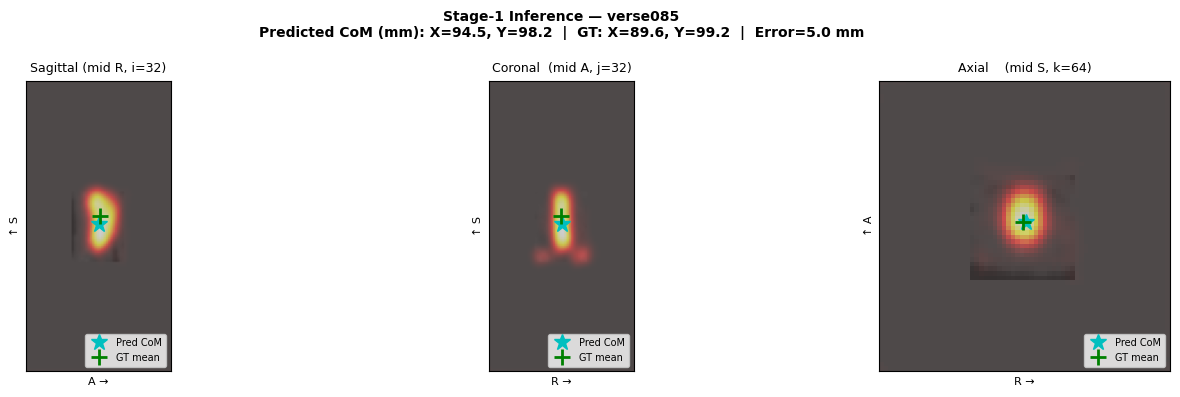


Running Stage-1 inference on: verse089
  Predicted spine center (mm):  X=89.2  Y=82.2
  GT spine center      (mm):   X=81.1  Y=88.0
  CoM voxel in [64×64×128] grid: (32.1, 33.3, 64.4)


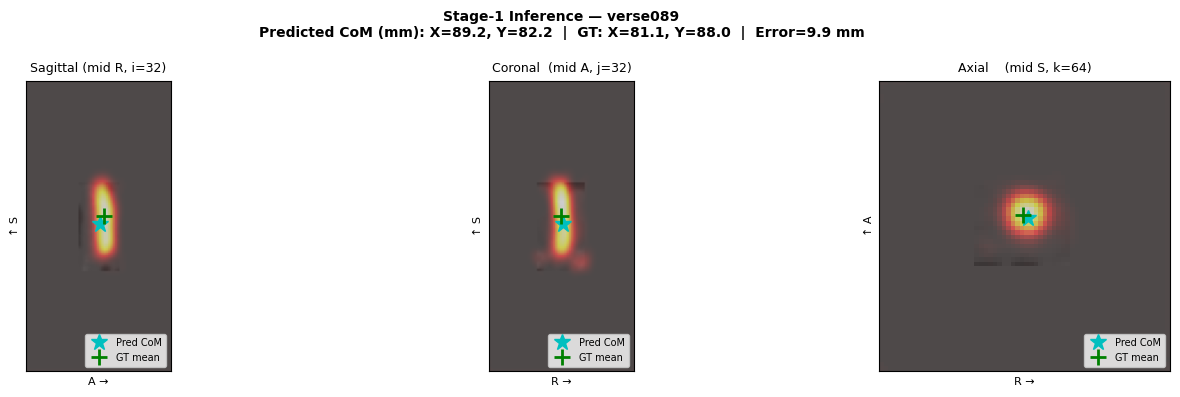


Running Stage-1 inference on: verse092
  Predicted spine center (mm):  X=210.7  Y=181.4
  GT spine center      (mm):   X=216.0  Y=157.2
  CoM voxel in [64×64×128] grid: (31.3, 27.7, 70.4)


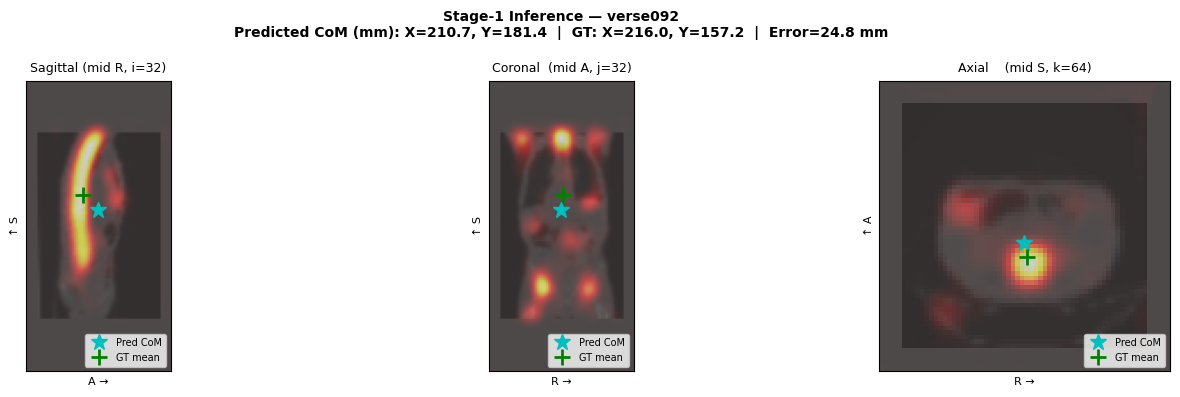


Running Stage-1 inference on: verse101
  Predicted spine center (mm):  X=174.0  Y=151.6
  GT spine center      (mm):   X=176.9  Y=128.0
  CoM voxel in [64×64×128] grid: (31.8, 29.0, 69.9)


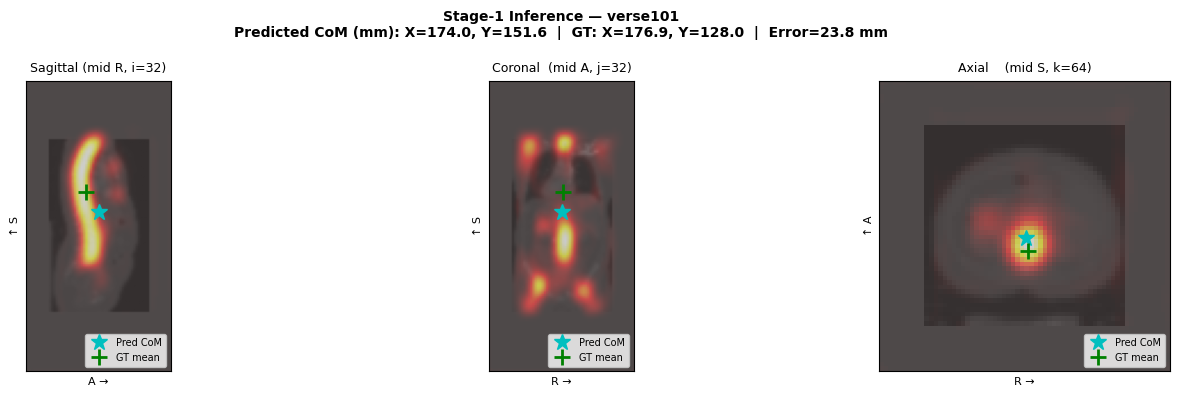


Running Stage-1 inference on: verse119
  Predicted spine center (mm):  X=43.9  Y=70.5
  GT spine center      (mm):   X=36.9  Y=65.8
  CoM voxel in [64×64×128] grid: (31.5, 32.8, 65.1)


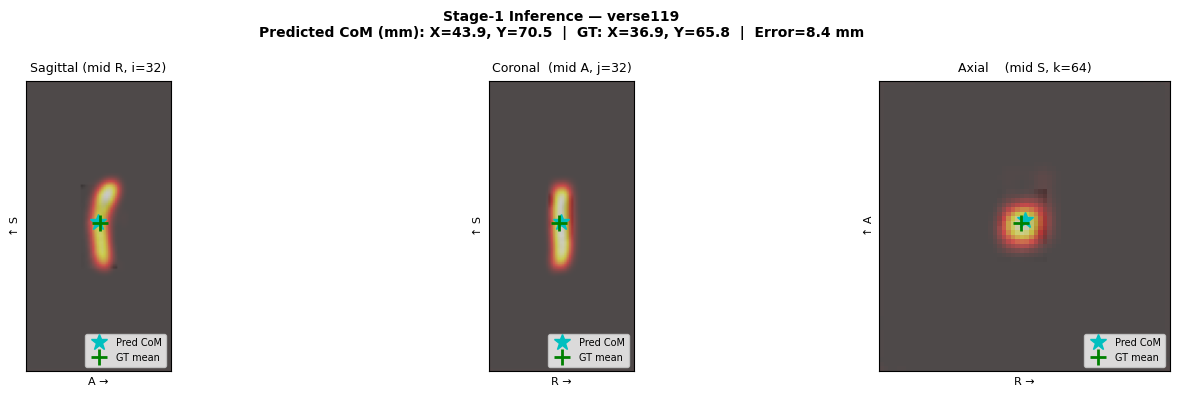


Running Stage-1 inference on: verse130
  Predicted spine center (mm):  X=88.0  Y=83.9
  GT spine center      (mm):   X=85.6  Y=84.8
  CoM voxel in [64×64×128] grid: (32.0, 31.5, 65.8)


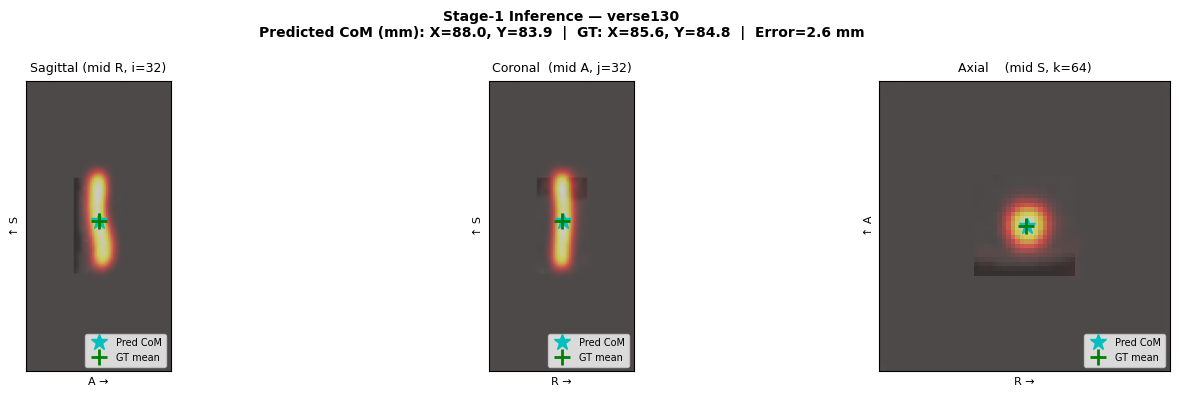


Running Stage-1 inference on: verse131
  Predicted spine center (mm):  X=44.4  Y=87.0
  GT spine center      (mm):   X=41.8  Y=88.9
  CoM voxel in [64×64×128] grid: (31.6, 31.9, 65.6)


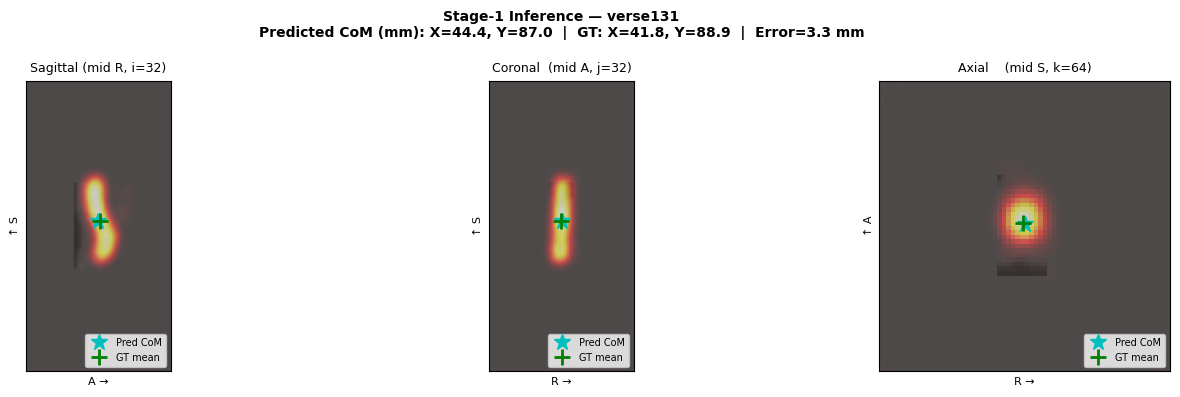


Running Stage-1 inference on: verse138
  Predicted spine center (mm):  X=189.7  Y=177.0
  GT spine center      (mm):   X=188.4  Y=155.6
  CoM voxel in [64×64×128] grid: (32.7, 31.1, 69.4)


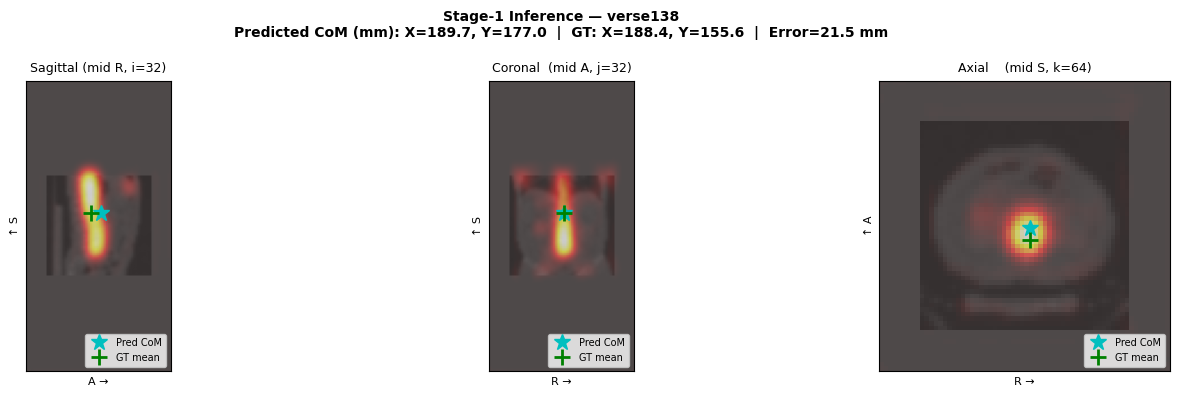


Running Stage-1 inference on: verse143
  Predicted spine center (mm):  X=80.0  Y=82.8
  GT spine center      (mm):   X=80.0  Y=84.8
  CoM voxel in [64×64×128] grid: (32.0, 32.4, 64.2)


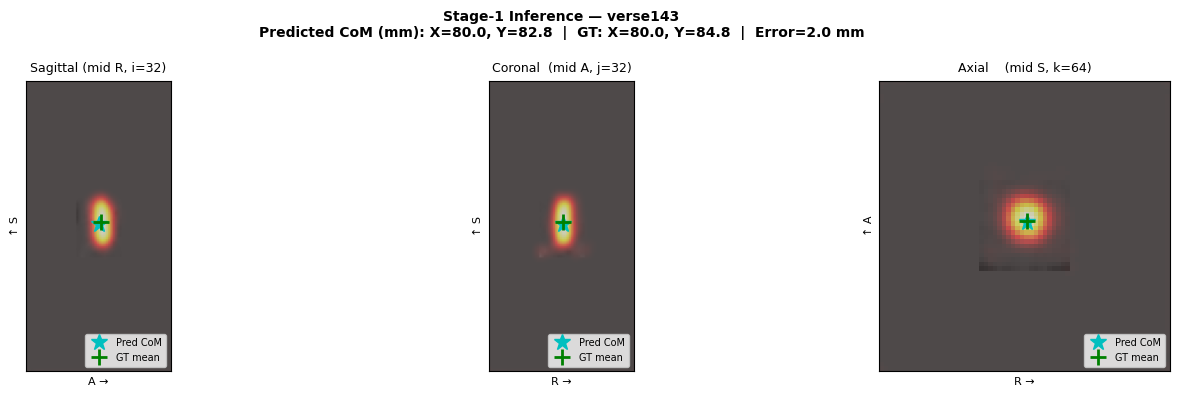


Running Stage-1 inference on: verse144
  Predicted spine center (mm):  X=89.8  Y=126.5
  GT spine center      (mm):   X=76.4  Y=139.6
  CoM voxel in [64×64×128] grid: (30.2, 34.8, 66.2)


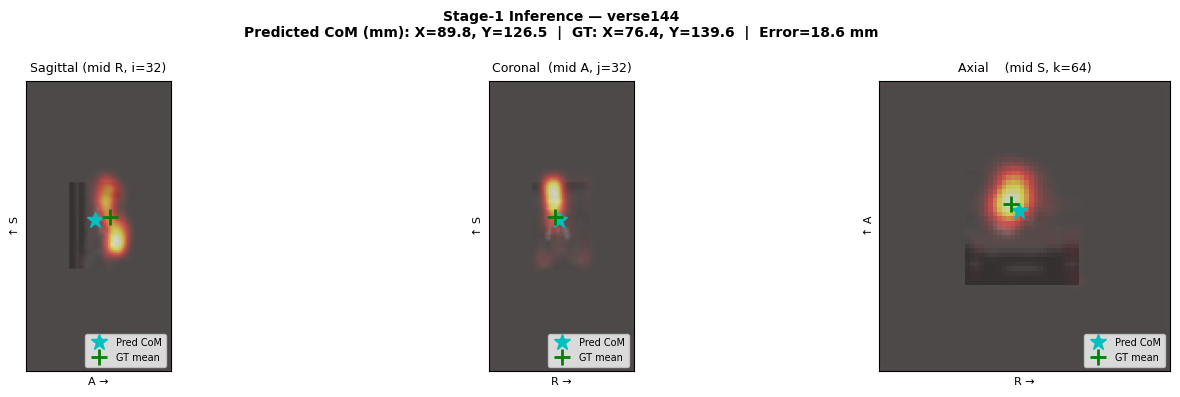


Running Stage-1 inference on: verse147
  Predicted spine center (mm):  X=70.8  Y=83.9
  GT spine center      (mm):   X=72.0  Y=91.2
  CoM voxel in [64×64×128] grid: (31.9, 33.5, 64.9)


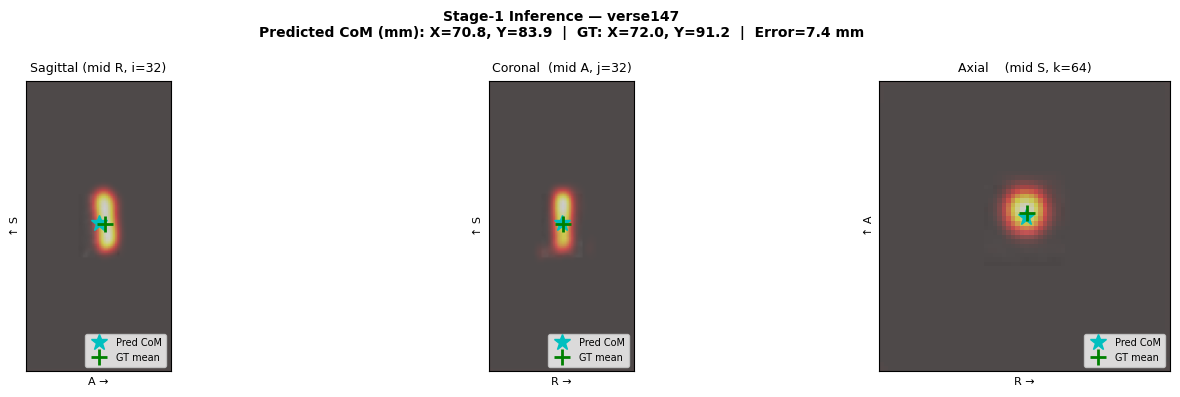


Running Stage-1 inference on: verse149
  Predicted spine center (mm):  X=73.9  Y=90.9
  GT spine center      (mm):   X=70.0  Y=104.0
  CoM voxel in [64×64×128] grid: (31.2, 33.4, 65.5)


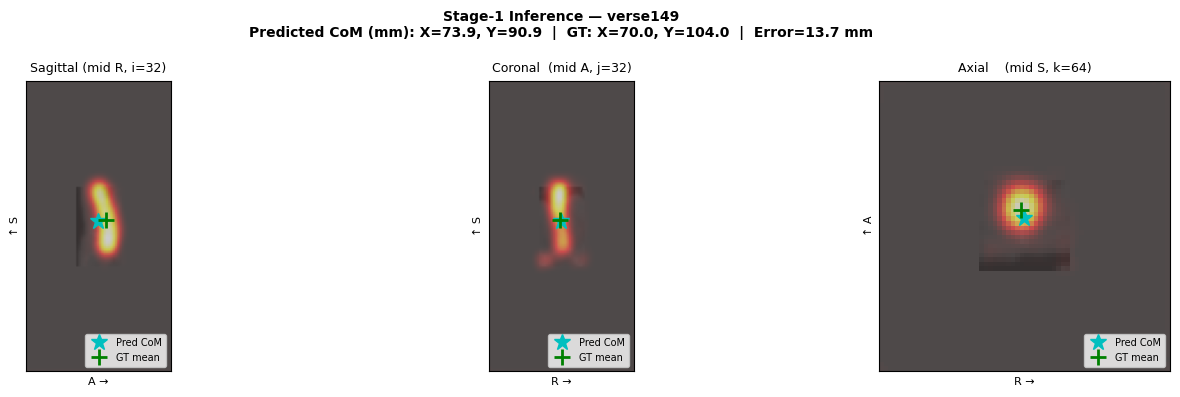


Running Stage-1 inference on: verse154
  Predicted spine center (mm):  X=248.7  Y=219.0
  GT spine center      (mm):   X=258.7  Y=186.7
  CoM voxel in [64×64×128] grid: (32.1, 28.4, 65.9)


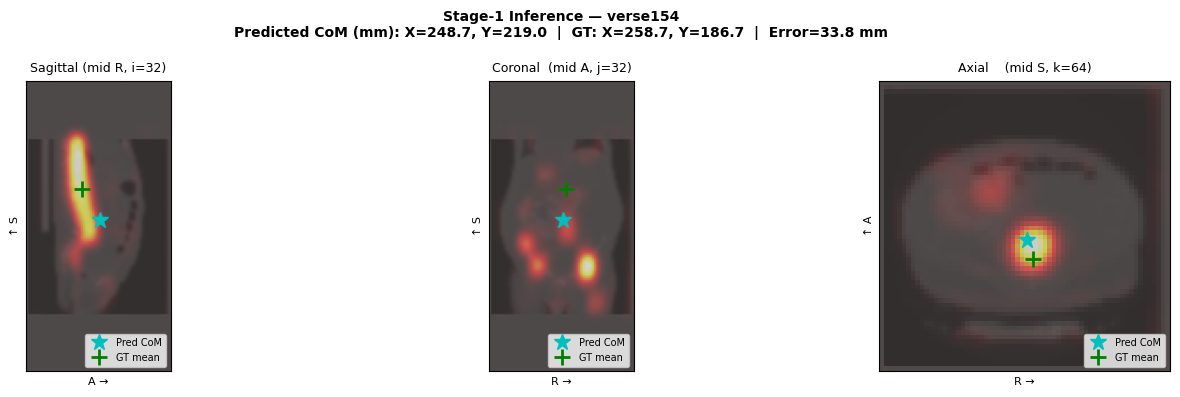


Running Stage-1 inference on: verse217
  Predicted spine center (mm):  X=109.2  Y=125.6
  GT spine center      (mm):   X=113.0  Y=125.0
  CoM voxel in [64×64×128] grid: (31.6, 33.7, 62.7)


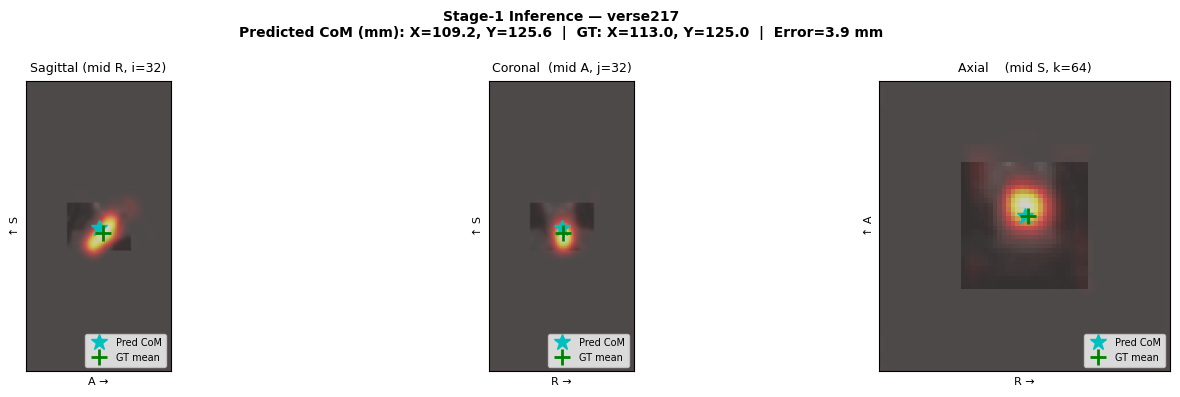


Running Stage-1 inference on: verse250
  Predicted spine center (mm):  X=35.6  Y=100.1
  GT spine center      (mm):   X=34.0  Y=117.0
  CoM voxel in [64×64×128] grid: (31.4, 33.5, 62.0)


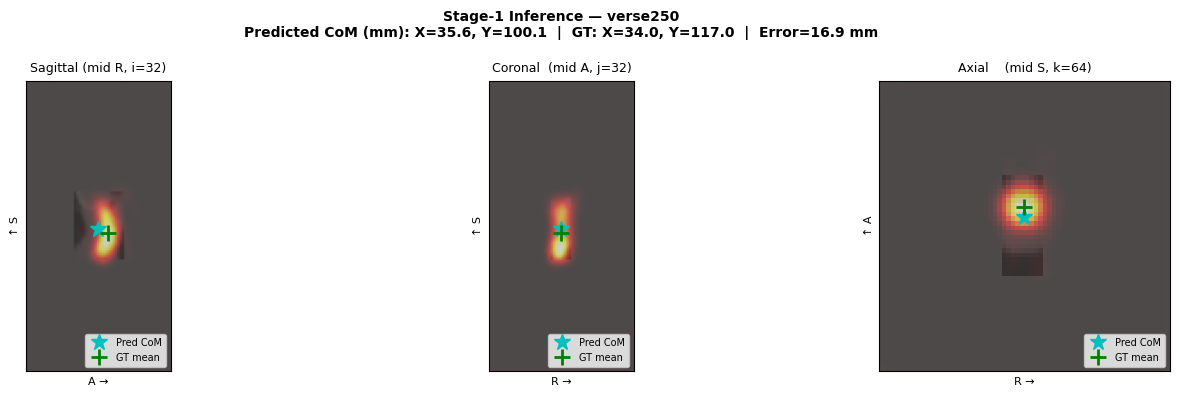


Running Stage-1 inference on: verse260
  Predicted spine center (mm):  X=62.7  Y=107.9
  GT spine center      (mm):   X=62.5  Y=114.0
  CoM voxel in [64×64×128] grid: (31.8, 33.5, 68.5)


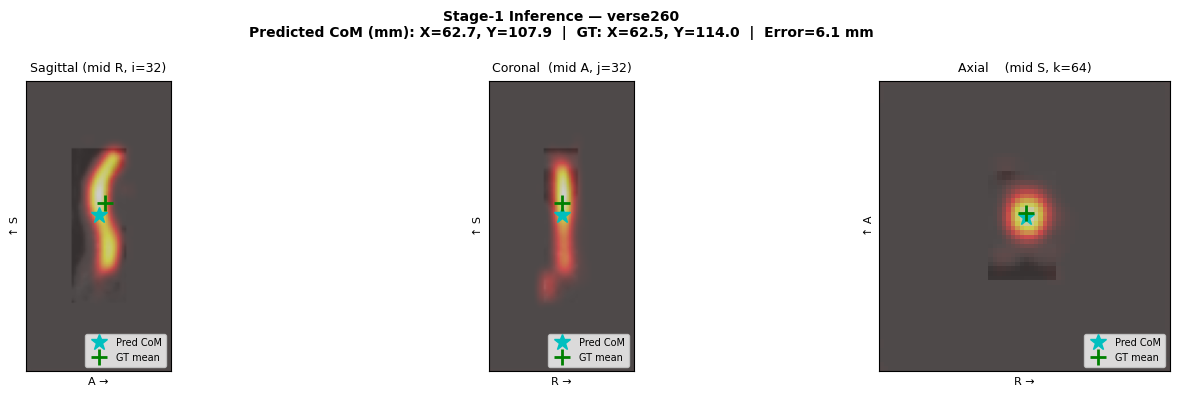


Running Stage-1 inference on: verse271
  Predicted spine center (mm):  X=114.2  Y=123.1
  GT spine center      (mm):   X=119.1  Y=113.9
  CoM voxel in [64×64×128] grid: (32.3, 33.4, 65.1)


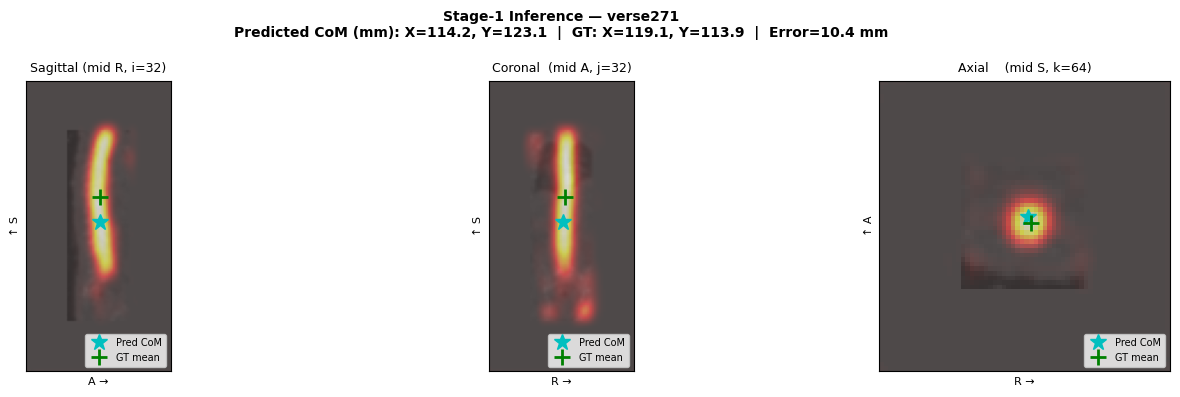


Running Stage-1 inference on: verse414_split-verse273
  Predicted spine center (mm):  X=65.7  Y=96.1
  GT spine center      (mm):   X=65.3  Y=91.1
  CoM voxel in [64×64×128] grid: (32.2, 34.0, 65.6)


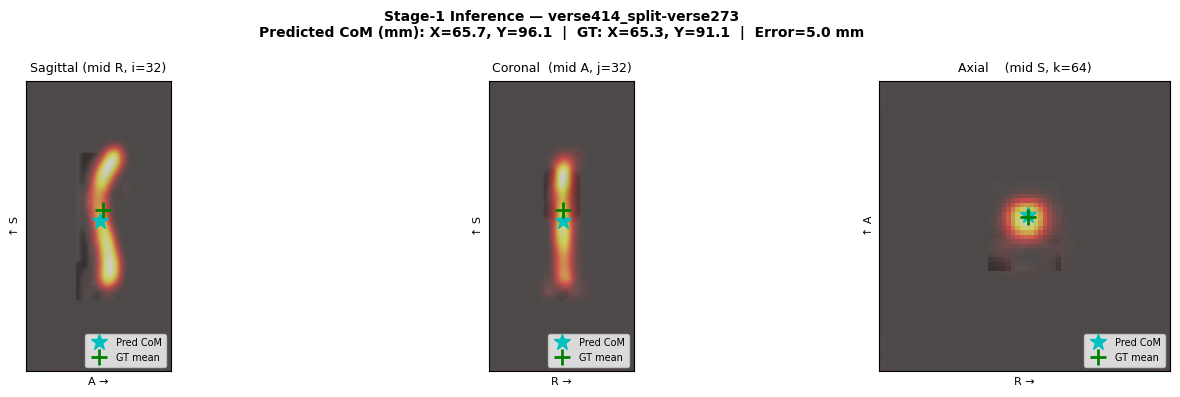


Running Stage-1 inference on: verse416_split-verse247
  Predicted spine center (mm):  X=49.1  Y=89.0
  GT spine center      (mm):   X=48.0  Y=99.4
  CoM voxel in [64×64×128] grid: (32.1, 33.1, 63.6)


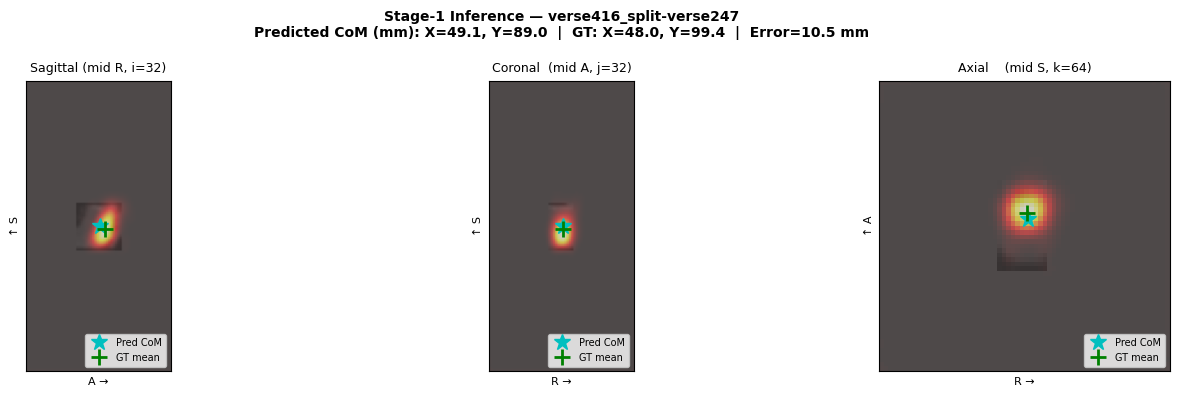


Running Stage-1 inference on: verse416_split-verse279
  Predicted spine center (mm):  X=96.0  Y=297.1
  GT spine center      (mm):   X=92.4  Y=282.2
  CoM voxel in [64×64×128] grid: (32.0, 28.1, 66.3)


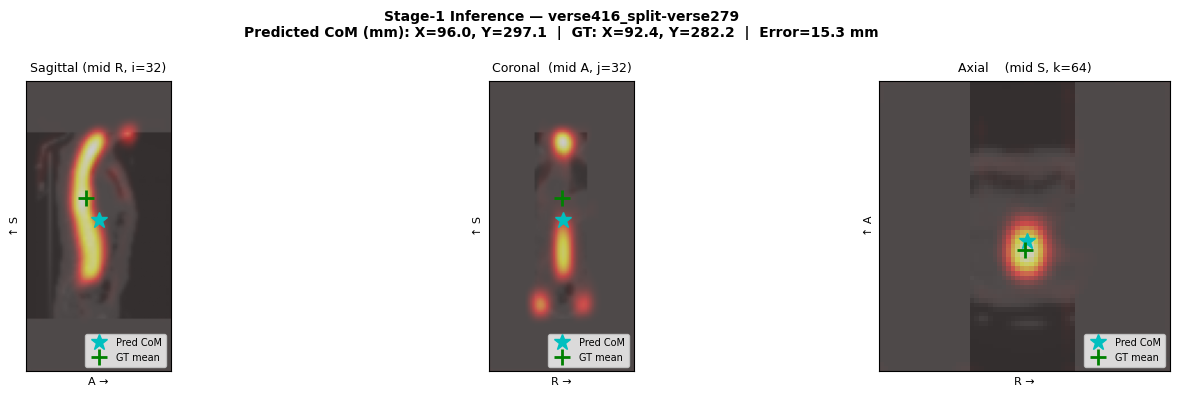


Running Stage-1 inference on: verse417_split-verse277
  Predicted spine center (mm):  X=53.2  Y=92.3
  GT spine center      (mm):   X=53.0  Y=94.0
  CoM voxel in [64×64×128] grid: (32.7, 32.5, 64.0)


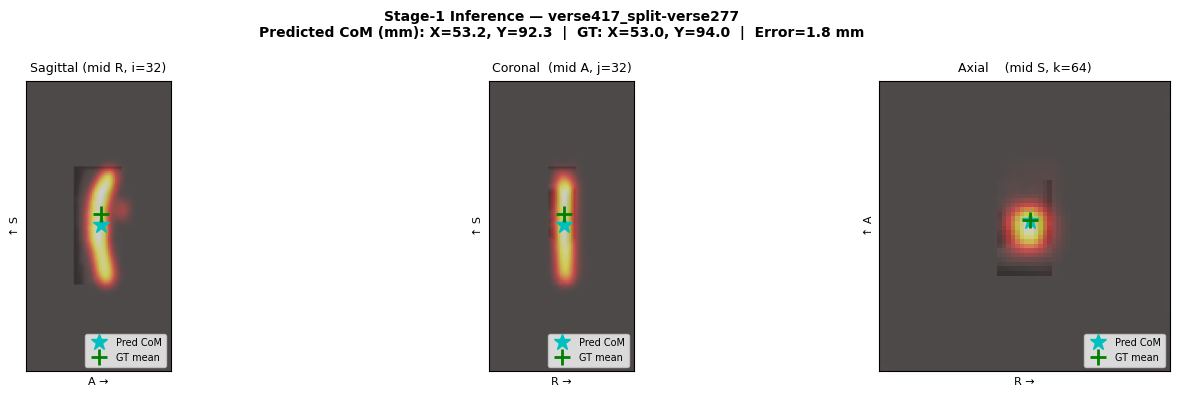


Running Stage-1 inference on: verse417_split-verse278
  Predicted spine center (mm):  X=71.9  Y=82.1
  GT spine center      (mm):   X=72.0  Y=90.3
  CoM voxel in [64×64×128] grid: (32.0, 33.3, 66.0)


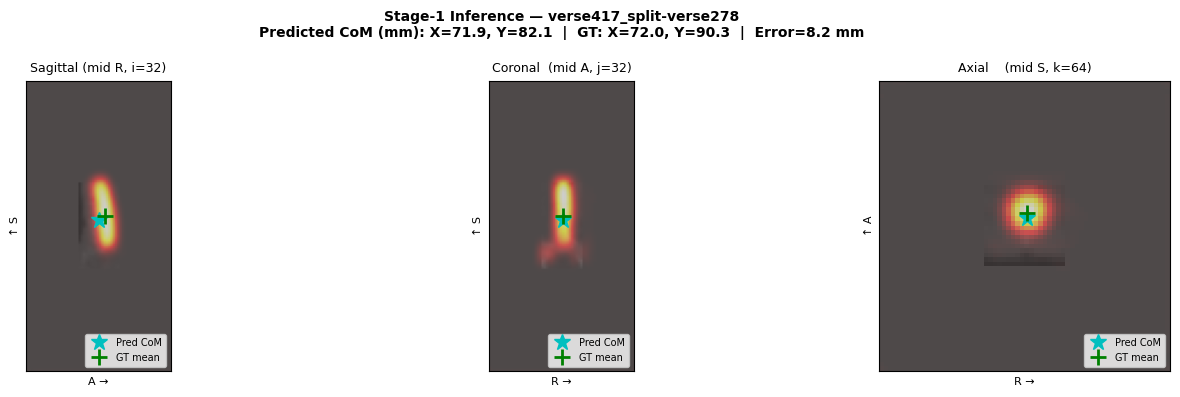


── Stage-1 Inference Summary ───────────────────────────────────────
                subject  com_x_mm  com_y_mm  gt_x_mm  gt_y_mm  error_mm
               verse012     56.28    108.49    56.00   112.00      3.52
               verse020     86.05    192.95    76.24   182.59     14.27
               verse029    152.02    190.17   147.29   161.41     29.14
               verse032     61.00    105.60    58.67   114.67      9.36
               verse038    172.35    159.14   160.00   107.43     53.17
               verse040    184.62    156.98   184.00   113.78     43.21
               verse050     90.56    238.80    88.94   229.18      9.76
               verse053     82.32    150.13    84.80   160.00     10.18
               verse054     58.63    105.24    52.80   115.20     11.54
               verse055    176.40    187.28   162.91   152.00     37.78
               verse059     34.83     97.52    41.14    92.57      8.02
               verse066     94.27    153.88    96.00   161.60     

In [11]:
import gc


def extract_spine_coordinate(predicted_heatmap, target_spacing=8.0, offset=None):
    """
    Extract the (X, Y) spine-center from the predicted centerline heatmap.

    Parameters
    ----------
    predicted_heatmap : np.ndarray  shape (64,64,128) — raw model output
    target_spacing    : float  — voxel spacing in mm (8.0 for Stage 1)
    offset            : np.ndarray (3,) or None
                        The pad/crop offset applied during preprocessing
                        (returned by center_pad_crop). Used to map voxel indices
                        back to the resampled (8mm, RAS) coordinate system.

    Returns
    -------
    com_x_mm, com_y_mm : float
        Physical (mm) coordinates in the 8mm-RAS space.
        Pass these directly to Stage 2 as the spine center.
    com_vox : tuple (ci, cj, ck)
        Voxel indices in the final [64×64×128] grid (for diagnostics).
    """
    # Clip negatives (ReLU) before computing center-of-mass
    hm_relu = np.maximum(predicted_heatmap, 0.0)

    if hm_relu.sum() == 0:
        ci, cj, ck = [s // 2 for s in predicted_heatmap.shape]
    else:
        ci, cj, ck = center_of_mass(hm_relu)

    com_vox = (float(ci), float(cj), float(ck))

    # Undo the pad/crop offset to get back to 8mm-RAS voxel space
    if offset is not None:
        ci -= offset[0]
        cj -= offset[1]
        ck -= offset[2]

    # RAS: axis-0=R(i), axis-1=A(j) → X=R, Y=A in mm
    com_x_mm = ci * target_spacing
    com_y_mm = cj * target_spacing

    return com_x_mm, com_y_mm, com_vox


# ── Load best checkpoint ───────────────────────────────────────────────────────
if os.path.exists(CFG["checkpoint_path"]):
    ckpt = torch.load(CFG["checkpoint_path"], map_location=device)
    model.load_state_dict(ckpt["model_state"])
    print(f"Loaded checkpoint from iteration {ckpt['iteration']}  "
          f"(val MSE={ckpt['val_loss']:.6f})")
else:
    print("No checkpoint found — using current model weights.")

model.eval()

# ── Inference loop ─────────────────────────────────────────────────────────────
df_test = pd.read_csv(CFG["csv_path"])
df_test = df_test[df_test["type"] == "test"].reset_index(drop=True)

inference_results = []

for _, row in df_test.iterrows():
    subj_name = row["name"]
    print(f"\nRunning Stage-1 inference on: {subj_name}")

    try:
        vol_nib_  = nib.load(str(row["image_path"]))
        _, raw_ctr = parse_centroid_json(str(row["centroid_json_path"]))

        vol_pp, centroids_pp, ras_affine, orig_affine = preprocess_stage1(
            vol_nib_, raw_ctr,
            target_spacing=CFG["target_spacing"],
            smooth_sigma=CFG["smooth_sigma"],
            divisor=CFG["intensity_divisor"],
            input_size=CFG["input_size"],
        )

        # Re-derive the pad/crop offset from the 8mm volume shape
        vol_ras_temp = reorient_to_ras(vol_nib_)
        zooms_temp   = np.array(vol_ras_temp.header.get_zooms()[:3], dtype=np.float64)
        shape_8mm    = tuple(int(round(s * z / CFG["target_spacing"]))
                             for s, z in zip(vol_ras_temp.shape, zooms_temp))
        _, offset = center_pad_crop(np.zeros(shape_8mm), CFG["input_size"])
        del vol_ras_temp

        inp_t = torch.from_numpy(vol_pp[None, None]).to(device)   # [1,1,64,64,128]

        with torch.no_grad():
            pred_hm = model(inp_t)[0, 0].cpu().numpy()            # [64,64,128]

        com_x_mm, com_y_mm, com_vox = extract_spine_coordinate(
            pred_hm, target_spacing=CFG["target_spacing"], offset=offset)

        # GT spine center: mean over all vertebrae in the final grid
        if centroids_pp:
            gt_xs = [v[0] for v in centroids_pp.values()]
            gt_ys = [v[1] for v in centroids_pp.values()]
            # MUST subtract offset here exactly as extract_spine_coordinate does
            gt_x_mm = (np.mean(gt_xs) - offset[0]) * CFG["target_spacing"]
            gt_y_mm = (np.mean(gt_ys) - offset[1]) * CFG["target_spacing"]
        else:
            gt_x_mm = gt_y_mm = float("nan")

        print(f"  Predicted spine center (mm):  X={com_x_mm:.1f}  Y={com_y_mm:.1f}")
        print(f"  GT spine center      (mm):   X={gt_x_mm:.1f}  Y={gt_y_mm:.1f}")
        print(f"  CoM voxel in [64×64×128] grid: {tuple(round(v,1) for v in com_vox)}")

        inference_results.append({
            "subject":   subj_name,
            "com_x_mm":  round(com_x_mm, 2),
            "com_y_mm":  round(com_y_mm, 2),
            "gt_x_mm":   round(gt_x_mm,  2),
            "gt_y_mm":   round(gt_y_mm,  2),
            "error_mm":  round(np.sqrt((com_x_mm - gt_x_mm)**2
                                       + (com_y_mm - gt_y_mm)**2), 2),
        })

        # ── Visualise — correct RAS ortho views with predicted vs GT overlay ──
        # RAS: axis-0=R(i), axis-1=A(j), axis-2=S(k)
        nr, na, ns = CFG["input_size"]
        mid_r, mid_a, mid_s = nr // 2, na // 2, ns // 2

        ci_vox, cj_vox, ck_vox = com_vox   # predicted CoM in the [64×64×128] grid
        gt_ci = np.mean(gt_xs) if centroids_pp else mid_r
        gt_cj = np.mean(gt_ys) if centroids_pp else mid_a

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        fig.suptitle(f"Stage-1 Inference — {subj_name}\n"
                     f"Predicted CoM (mm): X={com_x_mm:.1f}, Y={com_y_mm:.1f}  |  "
                     f"GT: X={gt_x_mm:.1f}, Y={gt_y_mm:.1f}  |  "
                     f"Error={inference_results[-1]['error_mm']:.1f} mm",
                     fontsize=10, fontweight="bold")

        # Sagittal (mid R): horizontal=A(j), vertical=S(k)  → overlay (cj, ck)
        axes[0].imshow(vol_pp[mid_r, :, :].T,  cmap="gray", origin="lower", vmin=-1, vmax=1, alpha=0.85)
        axes[0].imshow(np.maximum(pred_hm[mid_r, :, :], 0).T, cmap="hot", origin="lower", alpha=0.5)
        axes[0].plot(ci_vox, ck_vox, "c*",  markersize=12, label="Pred CoM")
        if centroids_pp:
            axes[0].plot(gt_cj, np.mean([v[2] for v in centroids_pp.values()]),
                         "g+", markersize=12, markeredgewidth=2, label="GT mean")
        axes[0].set_title(f"Sagittal (mid R, i={mid_r})", fontsize=9)
        axes[0].set_xlabel("A →", fontsize=8); axes[0].set_ylabel("↑ S", fontsize=8)
        axes[0].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        axes[0].legend(fontsize=7, loc="lower right")

        # Coronal (mid A): horizontal=R(i), vertical=S(k)  → overlay (ci, ck)
        axes[1].imshow(vol_pp[:, mid_a, :].T,  cmap="gray", origin="lower", vmin=-1, vmax=1, alpha=0.85)
        axes[1].imshow(np.maximum(pred_hm[:, mid_a, :], 0).T, cmap="hot", origin="lower", alpha=0.5)
        axes[1].plot(ci_vox, ck_vox, "c*",  markersize=12, label="Pred CoM")
        if centroids_pp:
            axes[1].plot(gt_ci, np.mean([v[2] for v in centroids_pp.values()]),
                         "g+", markersize=12, markeredgewidth=2, label="GT mean")
        axes[1].set_title(f"Coronal  (mid A, j={mid_a})", fontsize=9)
        axes[1].set_xlabel("R →", fontsize=8); axes[1].set_ylabel("↑ S", fontsize=8)
        axes[1].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        axes[1].legend(fontsize=7, loc="lower right")

        # Axial (mid S): horizontal=R(i), vertical=A(j)  → overlay (ci, cj)
        axes[2].imshow(vol_pp[:, :, mid_s].T,  cmap="gray", origin="lower", vmin=-1, vmax=1, alpha=0.85)
        axes[2].imshow(np.maximum(pred_hm[:, :, mid_s], 0).T, cmap="hot", origin="lower", alpha=0.5)
        axes[2].plot(ci_vox, cj_vox, "c*",  markersize=12, label="Pred CoM")
        if centroids_pp:
            axes[2].plot(gt_ci, gt_cj, "g+",
                         markersize=12, markeredgewidth=2, label="GT mean")
        axes[2].set_title(f"Axial    (mid S, k={mid_s})", fontsize=9)
        axes[2].set_xlabel("R →", fontsize=8); axes[2].set_ylabel("↑ A", fontsize=8)
        axes[2].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        axes[2].legend(fontsize=7, loc="lower right")

        plt.tight_layout(); plt.show()

        del vol_pp, pred_hm, vol_nib_
        gc.collect()

    except Exception as e:
        print(f"  ✗ Error: {e}")

# ── Summary table ──────────────────────────────────────────────────────────────
if inference_results:
    df_inf = pd.DataFrame(inference_results)
    print("\n── Stage-1 Inference Summary ───────────────────────────────────────")
    print(df_inf.to_string(index=False))
    valid = df_inf["error_mm"].dropna()
    print(f"\nMean spine-center error : {valid.mean():.1f} mm  ±  {valid.std():.1f} mm")
    print("\n✓  Pass com_x_mm and com_y_mm to Stage 2 as the spine X/Y center.")
else:
    print("No inference results. Run the training loop first.")


## 11. Evaluation Metrics — Localisation Error & Heatmap MSE

Stage 1 does **not** produce a segmentation mask, so Dice / Hausdorff are not applicable.
The two relevant metrics are:

**1. Spine-Center Localisation Error (mm)**

$$E_{\text{loc}} = \sqrt{(\hat{x} - x^*)^2 + (\hat{y} - y^*)^2}$$

where $(\hat{x}, \hat{y})$ is the predicted center-of-mass and $(x^*, y^*)$ is the
mean GT vertebra position, both in physical mm space.

**2. Heatmap MSE** — how well the predicted heatmap matches the GT centerline heatmap:

$$\text{MSE} = \frac{1}{N}\sum_{\mathbf{x}} \left(\hat{h}(\mathbf{x}) - h^*(\mathbf{x})\right)^2$$

Both metrics are computed **per subject** and summarised with mean ± std.


Evaluating: verse012 … MSE=0.00009  |  Loc Error=3.5 mm
Evaluating: verse020 … MSE=0.00023  |  Loc Error=14.3 mm
Evaluating: verse029 … MSE=0.00082  |  Loc Error=29.1 mm
Evaluating: verse032 … MSE=0.00012  |  Loc Error=9.4 mm
Evaluating: verse038 … MSE=0.00075  |  Loc Error=53.2 mm
Evaluating: verse040 … MSE=0.00079  |  Loc Error=43.2 mm
Evaluating: verse050 … MSE=0.00066  |  Loc Error=9.8 mm
Evaluating: verse053 … MSE=0.00012  |  Loc Error=10.2 mm
Evaluating: verse054 … MSE=0.00011  |  Loc Error=11.5 mm
Evaluating: verse055 … MSE=0.00081  |  Loc Error=37.8 mm
Evaluating: verse059 … MSE=0.00030  |  Loc Error=8.0 mm
Evaluating: verse066 … MSE=0.00018  |  Loc Error=7.9 mm
Evaluating: verse070 … MSE=0.00017  |  Loc Error=6.8 mm
Evaluating: verse081 … MSE=0.00012  |  Loc Error=3.5 mm
Evaluating: verse083 … MSE=0.00006  |  Loc Error=11.8 mm
Evaluating: verse085 … MSE=0.00022  |  Loc Error=5.0 mm
Evaluating: verse089 … MSE=0.00016  |  Loc Error=9.9 mm
Evaluating: verse092 … MSE=0.00090  |  L

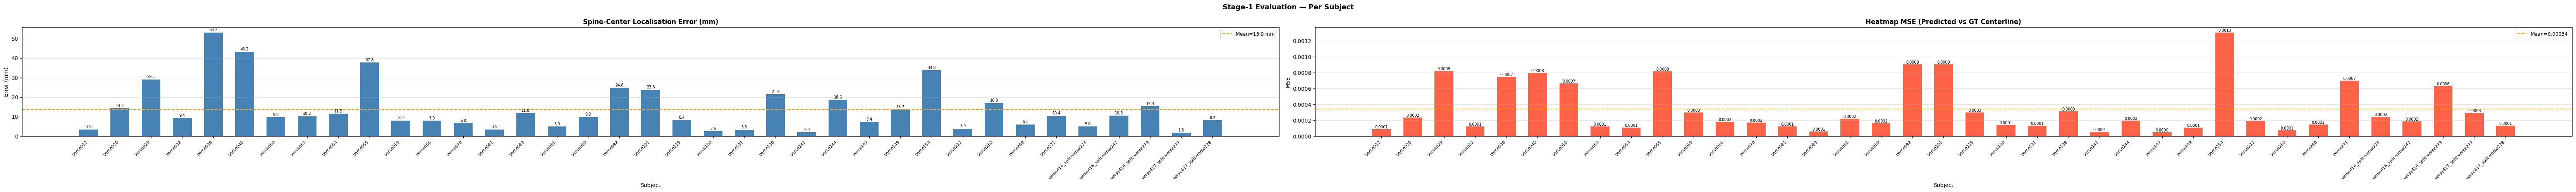

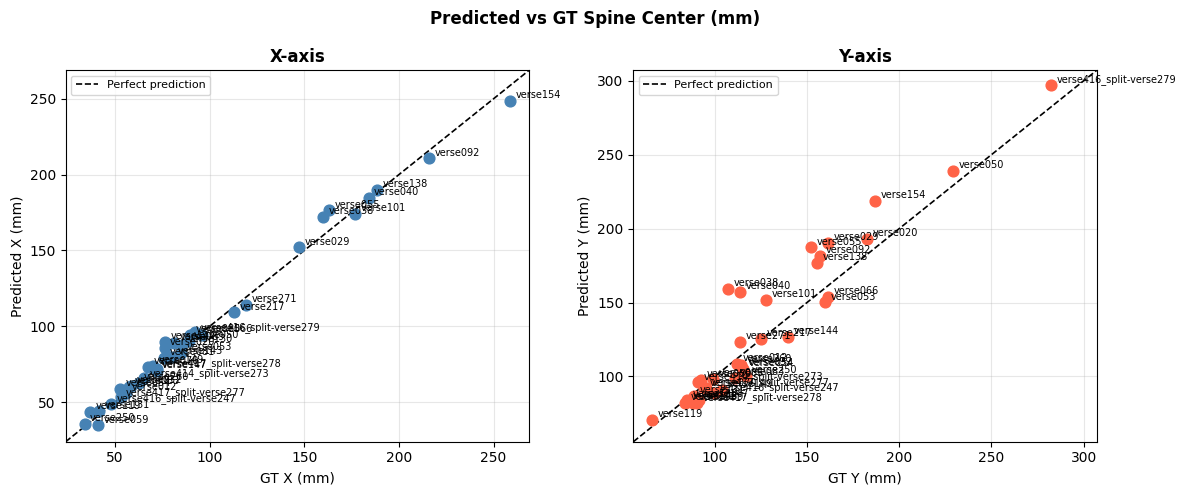

In [12]:
def compute_localisation_error(pred_hm, gt_centroids_vox, target_spacing, offset):
    """
    Compute the 2-D localisation error (mm) between the predicted spine center
    (center-of-mass of the heatmap) and the GT mean vertebra position.

    Parameters
    ----------
    pred_hm          : np.ndarray (64,64,128) — raw model output
    gt_centroids_vox : dict {label: (i,j,k)}  — GT centroids in the final [64,64,128] grid
    target_spacing   : float — mm per voxel (8.0)
    offset           : np.ndarray (3,) — pad/crop offset from center_pad_crop

    Returns
    -------
    error_mm   : float  — Euclidean error in mm (X-Y plane only)
    pred_x_mm  : float
    pred_y_mm  : float
    gt_x_mm    : float
    gt_y_mm    : float
    """
    pred_x_mm, pred_y_mm, _ = extract_spine_coordinate(pred_hm, target_spacing, offset)

    if gt_centroids_vox:
        gt_xs = [v[0] for v in gt_centroids_vox.values()]
        gt_ys = [v[1] for v in gt_centroids_vox.values()]
        # GT centroids are already in the final grid; undo offset before converting to mm
        gt_x_mm = (np.mean(gt_xs) - offset[0]) * target_spacing
        gt_y_mm = (np.mean(gt_ys) - offset[1]) * target_spacing
    else:
        gt_x_mm = gt_y_mm = float("nan")

    error_mm = float(np.sqrt((pred_x_mm - gt_x_mm)**2 + (pred_y_mm - gt_y_mm)**2))
    return error_mm, pred_x_mm, pred_y_mm, gt_x_mm, gt_y_mm


def compute_heatmap_mse(pred_hm, gt_hm):
    """MSE between predicted and GT heatmap arrays."""
    return float(np.mean((pred_hm - gt_hm) ** 2))


# ── Run evaluation on the test split ─────────────────────────────────────────
# Requires the best model to be loaded (done in cell 10 / inference cell above).

df_eval = pd.read_csv(CFG["csv_path"])
df_eval = df_eval[df_eval["type"] == "test"].reset_index(drop=True)

eval_rows = []

model.eval()

for _, row in df_eval.iterrows():
    subj_name = row["name"]
    print(f"Evaluating: {subj_name} … ", end="", flush=True)

    try:
        vol_nib_  = nib.load(str(row["image_path"]))
        _, raw_ctr = parse_centroid_json(str(row["centroid_json_path"]))

        vol_pp, centroids_pp, _, _ = preprocess_stage1(
            vol_nib_, raw_ctr,
            target_spacing=CFG["target_spacing"],
            smooth_sigma=CFG["smooth_sigma"],
            divisor=CFG["intensity_divisor"],
            input_size=CFG["input_size"],
        )

        # Recompute the pad/crop offset for this subject
        vol_ras_tmp = reorient_to_ras(vol_nib_)
        zooms_tmp   = np.array(vol_ras_tmp.header.get_zooms()[:3], dtype=np.float64)
        shape_8mm   = tuple(int(round(s * z / CFG["target_spacing"]))
                            for s, z in zip(vol_ras_tmp.shape, zooms_tmp))
        _, offset = center_pad_crop(np.zeros(shape_8mm), CFG["input_size"])
        del vol_ras_tmp

        # GT heatmap
        gt_hm = generate_spine_centerline_heatmap(
            centroids_pp, shape=CFG["input_size"], sigma=CFG["sigma_spine"])

        # Forward pass
        inp_t = torch.from_numpy(vol_pp[None, None]).to(device)
        with torch.no_grad():
            pred_hm = model(inp_t)[0, 0].cpu().numpy()

        # Metrics
        mse = compute_heatmap_mse(pred_hm, gt_hm)
        err, px, py, gx, gy = compute_localisation_error(
            pred_hm, centroids_pp, CFG["target_spacing"], offset)

        eval_rows.append({
            "subject":       subj_name,
            "heatmap_mse":   round(mse,  6),
            "loc_error_mm":  round(err,  2),
            "pred_x_mm":     round(px,   1),
            "pred_y_mm":     round(py,   1),
            "gt_x_mm":       round(gx,   1),
            "gt_y_mm":       round(gy,   1),
        })
        print(f"MSE={mse:.5f}  |  Loc Error={err:.1f} mm")

        del vol_pp, gt_hm, pred_hm, vol_nib_
        gc.collect()

    except Exception as e:
        print(f"✗ {e}")

# ── Summary table ─────────────────────────────────────────────────────────────
if eval_rows:
    df_res = pd.DataFrame(eval_rows)

    print("\n── Per-Subject Evaluation Results ──────────────────────────────────")
    print(df_res.to_string(index=False))

    print(f"\nHeatmap MSE      : {df_res['heatmap_mse'].mean():.6f}  "
          f"± {df_res['heatmap_mse'].std():.6f}")
    print(f"Loc Error (mm)   : {df_res['loc_error_mm'].mean():.2f}  "
          f"± {df_res['loc_error_mm'].std():.2f}")

    # ── Bar charts ────────────────────────────────────────────────────────────
    subjects_sorted = df_res["subject"].tolist()
    x = np.arange(len(subjects_sorted))

    fig, axes = plt.subplots(1, 2, figsize=(max(10, len(subjects_sorted) * 1.8), 5))
    fig.suptitle("Stage-1 Evaluation — Per Subject", fontsize=13, fontweight="bold")

    # Chart 1: Localisation error (mm)
    bars1 = axes[0].bar(x, df_res["loc_error_mm"], color="steelblue", width=0.6)
    axes[0].axhline(df_res["loc_error_mm"].mean(), color="orange", lw=1.5,
                    linestyle="--", label=f"Mean={df_res['loc_error_mm'].mean():.1f} mm")
    axes[0].set_title("Spine-Center Localisation Error (mm)", fontweight="bold")
    axes[0].set_ylabel("Error (mm)")
    axes[0].set_xlabel("Subject")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(subjects_sorted, rotation=45, ha="right", fontsize=8)
    axes[0].legend(fontsize=9)
    axes[0].grid(axis="y", alpha=0.3)
    for bar, val in zip(bars1, df_res["loc_error_mm"]):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                     f"{val:.1f}", ha="center", va="bottom", fontsize=7)

    # Chart 2: Heatmap MSE
    bars2 = axes[1].bar(x, df_res["heatmap_mse"], color="tomato", width=0.6)
    axes[1].axhline(df_res["heatmap_mse"].mean(), color="orange", lw=1.5,
                    linestyle="--", label=f"Mean={df_res['heatmap_mse'].mean():.5f}")
    axes[1].set_title("Heatmap MSE (Predicted vs GT Centerline)", fontweight="bold")
    axes[1].set_ylabel("MSE")
    axes[1].set_xlabel("Subject")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(subjects_sorted, rotation=45, ha="right", fontsize=8)
    axes[1].legend(fontsize=9)
    axes[1].grid(axis="y", alpha=0.3)
    for bar, val in zip(bars2, df_res["heatmap_mse"]):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                     f"{val:.4f}", ha="center", va="bottom", fontsize=7)

    plt.tight_layout()
    plt.show()

    # ── Scatter: predicted vs GT spine center (X and Y) ──────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Predicted vs GT Spine Center (mm)", fontsize=12, fontweight="bold")

    for ax, coord, color in [
        (axes[0], "x", "steelblue"),
        (axes[1], "y", "tomato"),
    ]:
        pred_vals = df_res[f"pred_{coord}_mm"]
        gt_vals   = df_res[f"gt_{coord}_mm"]
        lim = [min(pred_vals.min(), gt_vals.min()) - 10,
               max(pred_vals.max(), gt_vals.max()) + 10]
        ax.scatter(gt_vals, pred_vals, c=color, s=60, zorder=3)
        ax.plot(lim, lim, "k--", lw=1.2, label="Perfect prediction")
        for i, subj in enumerate(df_res["subject"]):
            ax.annotate(subj, (gt_vals.iloc[i], pred_vals.iloc[i]),
                        fontsize=7, textcoords="offset points", xytext=(4, 2))
        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel(f"GT {coord.upper()} (mm)")
        ax.set_ylabel(f"Predicted {coord.upper()} (mm)")
        ax.set_title(f"{coord.upper()}-axis", fontweight="bold")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

else:
    print("No evaluation results. Make sure inference has been run and the model is loaded.")
